<h1 style = "text-align:center">Exploratory Data Analysis Assignment</h1>

<h2>Contents</h2>

- [Importing Pertinent Libraries and Modules](#Importing-Pertinent-Libraries-and-Modules)
- [Importing the data from csv](#Importing-the-data-from-csv)
- [Changing Column Names and Data Types](#Changing-Column-Names-and-Data-Types)
1. [Data Cleaning](#1.-Data-Cleaning)
2. [Univariate Analysis across all Numerical Features](#2.-Univariate-Analysis-across-all-numerical-features)
3. [Univariate Analysis across all Categorical Features](#3.-Univariate-Analysis-across-all-categorical-features)
4. [Bivariate Analysis for Numerical to Numerical Features](#4.-Perform-Bivariate-Analysis-for-numerical-to-numerical-features)
5. [Bivariate Analysis for Categorical to Numerical Features](#5.-Perform-Bi-variate-Analysis-for-categorical-to-numerical-features)
6. [Bivariate Analysis for Market Feature againt Region, Category and Country Features](#6.-Perform-Bivariate-Analysis-for-Market-features-against-Region,-Category,-and-Country)

<h3>Importing Pertinent Libraries and Modules</h3>

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Importing the data from csv</h3>

In [2]:
df = pd.read_csv(r"superstore.csv")

In [3]:
df.sample(5)

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
30030,Furniture,Lippstadt,Germany,DK-129852,Darren Koutras,0.10,EU,1,00:00.0,ES-2013-3098610,...,246,Consumer,00:00.0,Second Class,22.50,North Rhine-Westphalia,Chairs,2013,EU,11
40463,Office Supplies,Auckland,New Zealand,AP-109151,Arthur Prichep,0.40,APAC,1,00:00.0,IN-2012-81623,...,33,Consumer,00:00.0,Standard Class,2.44,Auckland,Paper,2012,APAC,18
23552,Furniture,Saida,Algeria,CL-25651,Clay Ludtke,0.00,Africa,1,00:00.0,AG-2014-2760,...,516,Consumer,00:00.0,Standard Class,46.75,Saida,Chairs,2014,Africa,24
10455,Office Supplies,Datong,China,TC-215351,Tracy Collins,0.00,APAC,1,00:00.0,IN-2013-40218,...,27,Home Office,00:00.0,Standard Class,3.97,Shanxi,Paper,2013,APAC,5
29213,Technology,Muret,France,ON-187152,Odella Nelson,0.15,EU,1,00:00.0,IT-2011-1978668,...,284,Corporate,00:00.0,Second Class,23.67,Midi-Pyrénées,Phones,2011,EU,8


<h3>Changing Column Names and Data Types</h3>

In [4]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [6]:
pd.to_datetime(df['Order.Date']).unique()

<DatetimeArray>
['2026-07-18 00:00:00']
Length: 1, dtype: datetime64[ns]

In [7]:
pd.to_datetime(df["Ship.Date"]).unique()

<DatetimeArray>
['2026-07-18 00:00:00']
Length: 1, dtype: datetime64[ns]

In [8]:
df["Year"].unique()

array([2011, 2012, 2013, 2014])

In [9]:
pd.to_datetime(df["Year"],format = "%Y").dt.year.unique()

array([2011, 2012, 2013, 2014], dtype=int32)

In [10]:
col_name_mapper = {'Category': 'category', 
                   'City': 'city', 
                   'Country': 'country', 
                   'Customer.ID':'customer_id', 
                   'Customer.Name':'customer_name',
                   'Discount':'discount', 
                   'Market':'market', 
                   '记录数':'ji_lu_shu', 
                   'Order.Date':'order_date', 
                   'Order.ID':'order_id', 
                   'Order.Priority':'order_priority',
                   'Product.ID':'product_id', 
                   'Product.Name':'product_name', 
                   'Profit':'profit', 
                   'Quantity':'quantity', 
                   'Region':'region', 
                   'Row.ID':'row_id',
                   'Sales':'sales', 
                   'Segment':'segment', 
                   'Ship.Date':'ship_date', 
                   'Ship.Mode':'ship_mode', 
                   'Shipping.Cost':'shipping_cost', 
                   'State':'state',
                   'Sub.Category':'sub_category', 
                   'Year':'year', 
                   'Market2':'market2', 
                   'weeknum':'weeknum'}

In [11]:
data = df.rename(col_name_mapper, axis = 'columns')

In [12]:
data.sample(5)

,category,city,country,customer_id,customer_name,discount,market,ji_lu_shu,order_date,order_id,...,sales,segment,ship_date,ship_mode,shipping_cost,state,sub_category,year,market2,weeknum
38776,Furniture,Kayseri,Turkey,LW-69902,Lindsay Williams,0.6,EMEA,1,00:00.0,TU-2013-7830,...,7,Corporate,00:00.0,Standard Class,0.050,Kayseri,Furnishings,2013,EMEA,24
4643,Office Supplies,Paris,France,ON-187152,Odella Nelson,0.0,EU,1,00:00.0,ES-2011-1846006,...,27,Corporate,00:00.0,First Class,1.750,Ile-de-France,Binders,2011,EU,53
5165,Office Supplies,Ciego de Ávila,Cuba,GM-146953,Greg Maxwell,0.0,LATAM,1,00:00.0,MX-2014-116806,...,42,Corporate,00:00.0,First Class,7.375,Ciego de Ávila,Binders,2014,LATAM,46
46081,Technology,Sydney,Australia,DS-131801,David Smith,0.1,APAC,1,00:00.0,ID-2014-43060,...,260,Corporate,00:00.0,Standard Class,22.490,New South Wales,Accessories,2014,APAC,36
4178,Office Supplies,Guadalajara,Mexico,AH-101203,Adrian Hane,0.0,LATAM,1,00:00.0,MX-2012-161704,...,18,Home Office,00:00.0,Second Class,1.644,Jalisco,Fasteners,2012,LATAM,50


In [13]:
data.columns

Index(['category', 'city', 'country', 'customer_id', 'customer_name',
       'discount', 'market', 'ji_lu_shu', 'order_date', 'order_id',
       'order_priority', 'product_id', 'product_name', 'profit', 'quantity',
       'region', 'row_id', 'sales', 'segment', 'ship_date', 'ship_mode',
       'shipping_cost', 'state', 'sub_category', 'year', 'market2', 'weeknum'],
      dtype='object')

In [14]:
dtype_mapper = {'category':'category', 
                'city':'string', 
                'country':'string', 
                'customer_id':'string', 
                'customer_name':'string', 
                'discount':'float32',
                'market':'category', 
                'ji_lu_shu':'int16', 
                'order_date':'datetime64[ns]', 
                'order_id':'string', 
                'order_priority':'category',
                'product_id':'string', 
                'product_name':'string', 
                'profit':'float32', 
                'quantity':'int64', 
                'region':'string', 
                'row_id':'string',
                'sales':'int64', 
                'segment':'category', 
                'ship_date':'datetime64[ns]', 
                'ship_mode':'category', 
                'shipping_cost':'float32', 
                'state':'string',
                'sub_category':'category', 
               # 'year':'datetime64[ns]', 
                'market2':'category', 
                'weeknum':'int32'
               }

In [15]:
data = data.astype(dtype_mapper)
data["year"] = pd.to_datetime(data["year"],format = "%Y").dt.year
data["ship_date"] = pd.to_datetime(data["ship_date"]).dt.date
data["order_date"] = pd.to_datetime(data["order_date"]).dt.date

In [16]:
data.describe(include = np.number)

,discount,ji_lu_shu,profit,quantity,sales,shipping_cost,year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.000000,51285.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610985,3.476545,246.498440,26.378063,2012.777208,31.287112
std,0.212249,0.0,174.340347,2.278766,487.567175,57.298840,1.098931,14.429795
min,0.000000,1.0,-6599.978027,1.000000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810001,5.000000,251.000000,24.450001,2014.000000,44.000000
max,0.850000,1.0,8399.975586,14.000000,22638.000000,933.570007,2014.000000,53.000000


In [17]:
data.describe(exclude = np.number)

,category,city,country,customer_id,customer_name,market,order_date,order_id,order_priority,product_id,product_name,region,row_id,segment,ship_date,ship_mode,state,sub_category,market2
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51287,51290,51290
unique,3,3636,147,4873,795,7,1,25035,4,10292,3788,13,51290,3,1,4,1094,17,6
top,Office Supplies,New York City,United States,JG-158051,Muhammed Yedwab,APAC,2026-07-18,CA-2014-100111,Medium,OFF-AR-10003651,Staples,Central,36624,Consumer,2026-07-18,Standard Class,California,Binders,APAC
freq,31273,915,9994,40,108,11002,51290,14,29433,35,227,11117,1,26518,51290,30775,2001,6152,11002


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   category        51290 non-null  category
 1   city            51290 non-null  string  
 2   country         51290 non-null  string  
 3   customer_id     51290 non-null  string  
 4   customer_name   51290 non-null  string  
 5   discount        51290 non-null  float32 
 6   market          51290 non-null  category
 7   ji_lu_shu       51290 non-null  int16   
 8   order_date      51290 non-null  object  
 9   order_id        51290 non-null  string  
 10  order_priority  51290 non-null  category
 11  product_id      51290 non-null  string  
 12  product_name    51290 non-null  string  
 13  profit          51290 non-null  float32 
 14  quantity        51290 non-null  int64   
 15  region          51290 non-null  string  
 16  row_id          51290 non-null  string  
 17  sales       

<h3>1. Data Cleaning</h3>

<h4>1.a) Handling Missing Values</h4>

In [19]:
data.isnull().sum()

category          0
city              0
country           0
customer_id       0
customer_name     0
discount          0
market            0
ji_lu_shu         0
order_date        0
order_id          0
order_priority    0
product_id        0
product_name      0
profit            0
quantity          0
region            0
row_id            0
sales             0
segment           0
ship_date         0
ship_mode         0
shipping_cost     5
state             3
sub_category      0
year              0
market2           0
weeknum           0
dtype: int64

In [20]:
data = data.dropna()

In [21]:
#data.isnull().sum()

<h4>1.b) Duplicate Rows</h4>

In [22]:
data.duplicated().sum()

np.int64(0)

<h4>1.c) Unknown Columns</h4>

In [23]:
data = data.drop('ji_lu_shu', axis = 1)

In [24]:
data.columns

Index(['category', 'city', 'country', 'customer_id', 'customer_name',
       'discount', 'market', 'order_date', 'order_id', 'order_priority',
       'product_id', 'product_name', 'profit', 'quantity', 'region', 'row_id',
       'sales', 'segment', 'ship_date', 'ship_mode', 'shipping_cost', 'state',
       'sub_category', 'year', 'market2', 'weeknum'],
      dtype='object')

<h4>1.d) Check for Shape, Size and DataTypes</h4>

In [25]:
data.shape

(51282, 26)

In [26]:
data.size

1333332

In [27]:
data.dtypes

category                category
city              string[python]
country           string[python]
customer_id       string[python]
customer_name     string[python]
discount                 float32
market                  category
order_date                object
order_id          string[python]
order_priority          category
product_id        string[python]
product_name      string[python]
profit                   float32
quantity                   int64
region            string[python]
row_id            string[python]
sales                      int64
segment                 category
ship_date                 object
ship_mode               category
shipping_cost            float32
state             string[python]
sub_category            category
year                       int32
market2                 category
weeknum                    int32
dtype: object

<h3>2. Univariate Analysis across all numerical features</h3>

In [28]:
numerical_features = list(data.describe(include = np.number).columns)

In [29]:
numerical_features

['discount', 'profit', 'quantity', 'sales', 'shipping_cost', 'year', 'weeknum']

****************************************************************************************************
                                              DISCOUNT                                              
****************************************************************************************************
                                  1. Measures of Central Tendency                                   
The Mean for discount is 0.14
The Median for discount is 0.00
The Mode for discount is 0.00
                                     2. Measures of Dispersion                                      
The Standard Deviation for discount is 0.21
The Variance for discount is 0.05
The Range for discount is 0.85
The Inter Quartile Range for discount is 0.20
                                        3. Measures of Shape                                        
The Skewness of discount is 1.39.
The Kurtosis of discount is 0.72
                                          4. Visualization                      

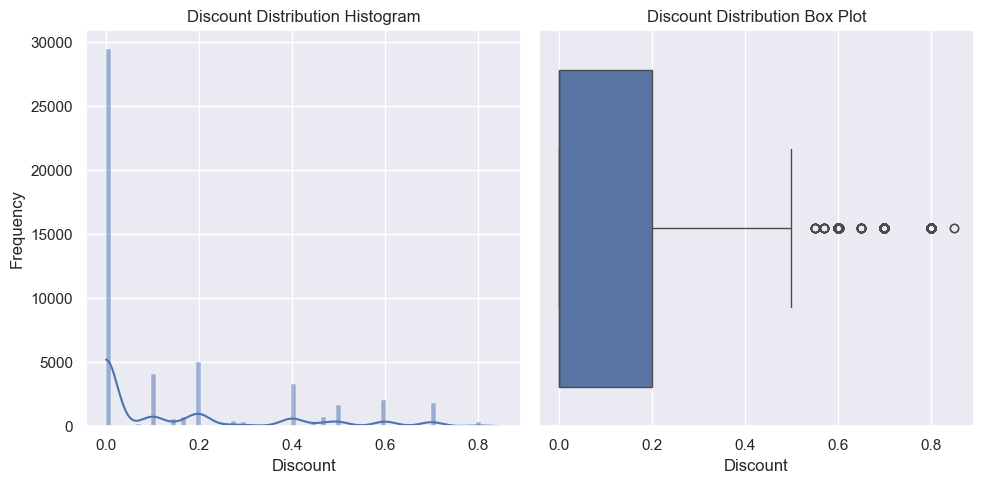

****************************************************************************************************
                                               PROFIT                                               
****************************************************************************************************
                                  1. Measures of Central Tendency                                   
The Mean for profit is 28.61
The Median for profit is 9.24
The Mode for profit is 0.00
                                     2. Measures of Dispersion                                      
The Standard Deviation for profit is 174.35
The Variance for profit is 30,399.19
The Range for profit is 14,999.95
The Inter Quartile Range for profit is 36.81
                                        3. Measures of Shape                                        
The Skewness of profit is 4.16.
The Kurtosis of profit is 291.37
                                          4. Visualization                        

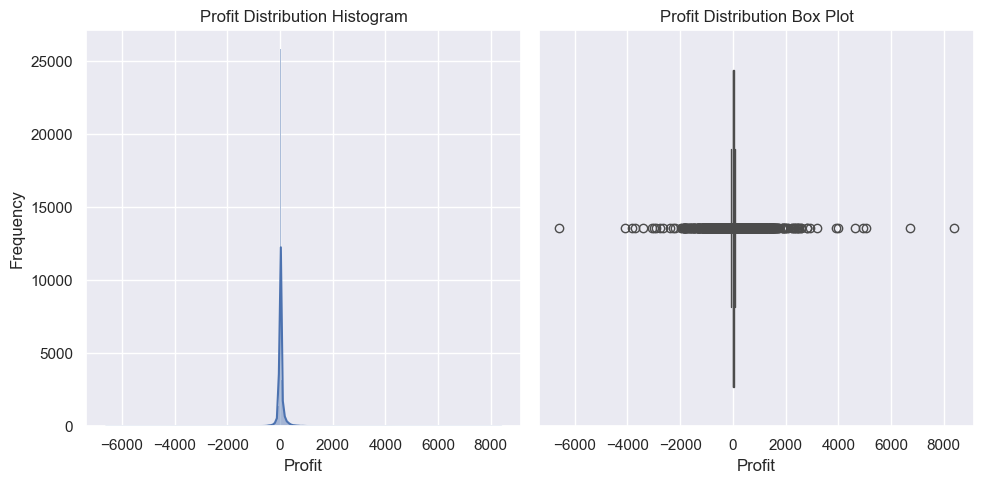

****************************************************************************************************
                                              QUANTITY                                              
****************************************************************************************************
                                  1. Measures of Central Tendency                                   
The Mean for quantity is 3.48
The Median for quantity is 3.00
The Mode for quantity is 2.00
                                     2. Measures of Dispersion                                      
The Standard Deviation for quantity is 2.28
The Variance for quantity is 5.19
The Range for quantity is 13.00
The Inter Quartile Range for quantity is 3.00
                                        3. Measures of Shape                                        
The Skewness of quantity is 1.36.
The Kurtosis of quantity is 2.28
                                          4. Visualization                     

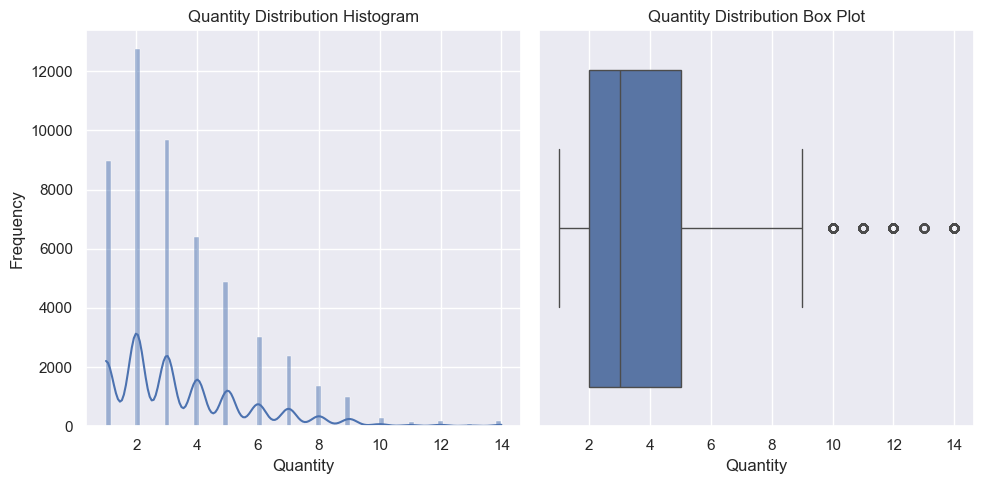

****************************************************************************************************
                                               SALES                                                
****************************************************************************************************
                                  1. Measures of Central Tendency                                   
The Mean for sales is 246.53
The Median for sales is 85.00
The Mode for sales is 13.00
                                     2. Measures of Dispersion                                      
The Standard Deviation for sales is 487.60
The Variance for sales is 237,751.34
The Range for sales is 22,638.00
The Inter Quartile Range for sales is 220.00
                                        3. Measures of Shape                                        
The Skewness of sales is 8.14.
The Kurtosis of sales is 176.70
                                          4. Visualization                            

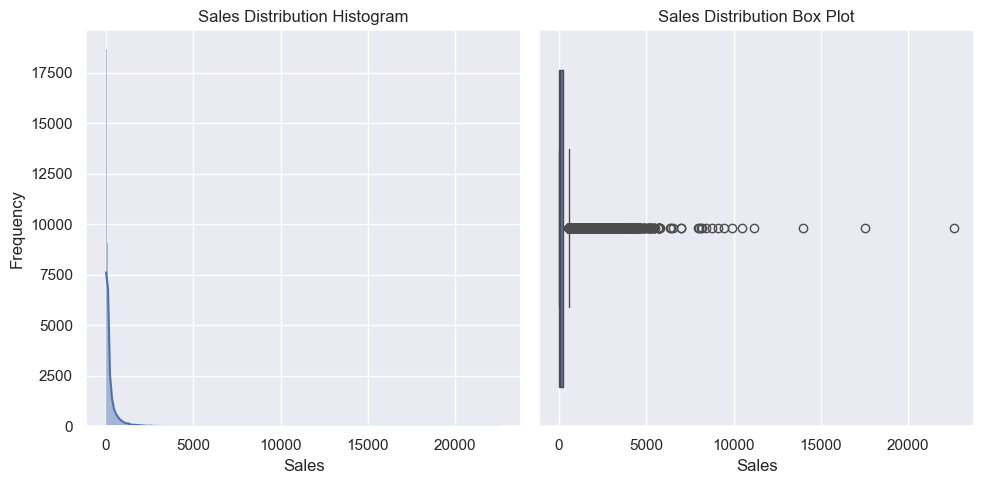

****************************************************************************************************
                                           SHIPPING_COST                                            
****************************************************************************************************
                                  1. Measures of Central Tendency                                   
The Mean for shipping_cost is 26.38
The Median for shipping_cost is 7.79
The Mode for shipping_cost is 0.35
                                     2. Measures of Dispersion                                      
The Standard Deviation for shipping_cost is 57.30
The Variance for shipping_cost is 3,283.31
The Range for shipping_cost is 933.57
The Inter Quartile Range for shipping_cost is 21.84
                                        3. Measures of Shape                                        
The Skewness of shipping_cost is 5.86.
The Kurtosis of shipping_cost is 50.01
                         

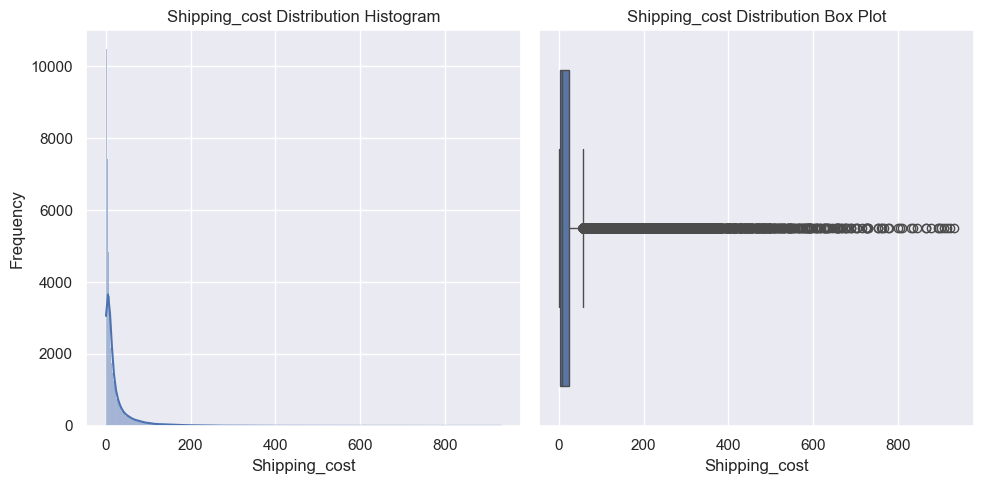

****************************************************************************************************
                                                YEAR                                                
****************************************************************************************************
                                  1. Measures of Central Tendency                                   
The Mean for year is 2,012.78
The Median for year is 2,013.00
The Mode for year is 2,014.00
                                     2. Measures of Dispersion                                      
The Standard Deviation for year is 1.10
The Variance for year is 1.21
The Range for year is 3.00
The Inter Quartile Range for year is 2.00
                                        3. Measures of Shape                                        
The Skewness of year is -0.34.
The Kurtosis of year is -1.22
                                          4. Visualization                                          


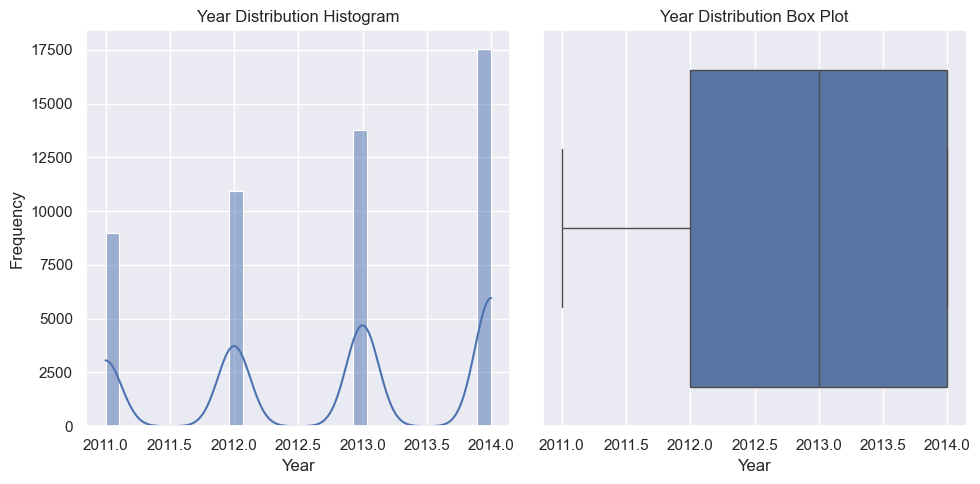

****************************************************************************************************
                                              WEEKNUM                                               
****************************************************************************************************
                                  1. Measures of Central Tendency                                   
The Mean for weeknum is 31.29
The Median for weeknum is 33.00
The Mode for weeknum is 47.00
                                     2. Measures of Dispersion                                      
The Standard Deviation for weeknum is 14.43
The Variance for weeknum is 208.21
The Range for weeknum is 52.00
The Inter Quartile Range for weeknum is 24.00
                                        3. Measures of Shape                                        
The Skewness of weeknum is -0.34.
The Kurtosis of weeknum is -0.98
                                          4. Visualization                     

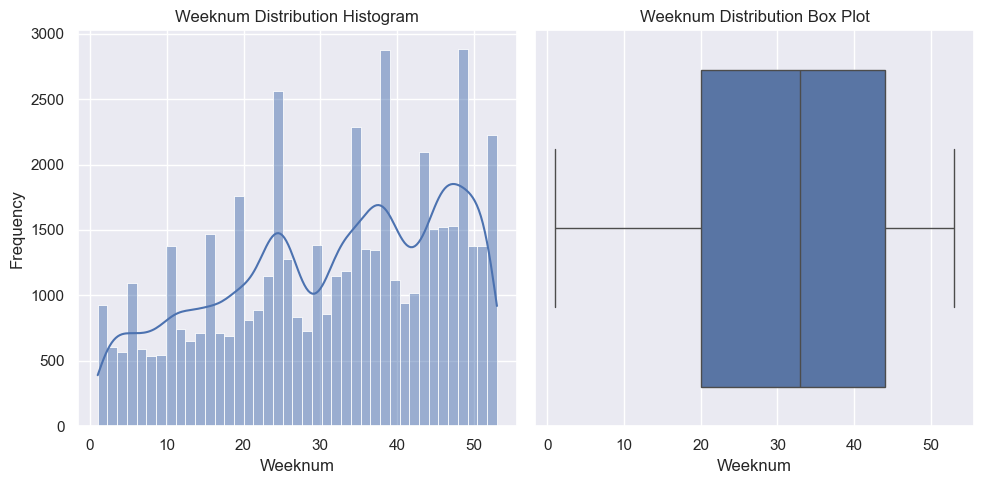

In [30]:
sns.set_theme()
for feature in numerical_features:
    print("*"*100)
    print(feature.upper().center(100," "))
    print("*"*100)
    
    print("="*100)
    print("1. Measures of Central Tendency".center(100," "))
    print("="*100)
    
    print("The Mean for {} is {:,.2f}".format(feature,data[feature].mean()))
    print("The Median for {} is {:,.2f}".format(feature,data[feature].median()))
    mode = data[feature].mode()
    mode_val = mode[0] if not mode.empty else np.nan
    print("The Mode for {} is {:,.2f}".format(feature,mode_val))
    print("="*100)
    
    print("2. Measures of Dispersion".center(100," "))
    print("="*100)
    print("The Standard Deviation for {} is {:,.2f}".format(feature,data[feature].std()))
    print("The Variance for {} is {:,.2f}".format(feature,data[feature].var()))
    rng = data[feature].max() - data[feature].min()
    print("The Range for {} is {:,.2f}".format(feature, rng))
    iqr = data[feature].quantile(0.75) - data[feature].quantile(0.25)
    print("The Inter Quartile Range for {} is {:,.2f}".format(feature,iqr))
    print("="*100)
   
    print("3. Measures of Shape".center(100," "))
    print("="*100)
    print("The Skewness of {} is {:,.2f}.".format(feature,data[feature].skew()))
    print("The Kurtosis of {} is {:,.2f}".format(feature, data[feature].kurt()))
    print("="*100)
   
    print("4. Visualization".center(100," "))
    print("="*100)
    fig, ax = plt.subplots(1, 2, figsize = (10, 5))
    
    sns.histplot(data = data, x = feature, kde = True, ax = ax[0])
    ax[0].set_xlabel(feature.capitalize())
    ax[0].set_ylabel("Frequency")
    ax[0].set_title(f"{feature.capitalize()} Distribution Histogram")

    sns.boxplot(data = data, x = feature,ax = ax[1])
    ax[1].set_xlabel(feature.capitalize())
    ax[1].set_title(f"{feature.capitalize()} Distribution Box Plot")

    plt.tight_layout()
    plt.show()

<h4>2. a)Which features seem useless in the analysis? Explain why?</h4>

The weeknum feature seems to be the most functionally useless in the data provided here. Although, it represents as a number, it is a discrete,cyclical time component. Measures of central tendency like mean, median and mode and shape like standard deviation and variance for weeknum have no real mathematical meaning. 

<h4>2.b) Which features are uniformly distributed or normally distributed?</h4>


- The weeknum feature is closest to being uniformally distributed. Its distribution histogram shows counts spread relatively evenly acorss the weeks, its skewness is close to zero(-0.34) and its kurtosis, -0.98, indicates  a flat-topped shape characteristic of uniform distribution.
- None of the other features are normally distributed. 

<h4>2.c)Which features are right-skewed/left-skewed? What does this signify?</h4>

- Based on the Descriptive Statistics above, the following features are right/positively skewed: discount(1.39), profit(4.16), quantity(1.36), sales(8.14), shipping_cost(5.86).
- It explains that vast majority of the transactions are of small value and only a few of them are massive which are pulling the mean forward. 

<h4>2.d)Which features have a high number of outliers, and discuss the impact?</h4>

- The features with the highest number of outliers are shipping_cost, sales and profit. Their high kurtosis value indicates heavy tails.
- The heavy tailed outliers will completely dominate and distort the data. 

<h3>3. Univariate Analysis across all categorical features</h3>

In [40]:
categorical_features = list(data.describe(exclude  = np.number).columns)
categorical_features

['category',
 'city',
 'country',
 'customer_id',
 'customer_name',
 'market',
 'order_date',
 'order_id',
 'order_priority',
 'product_id',
 'product_name',
 'region',
 'row_id',
 'segment',
 'ship_date',
 'ship_mode',
 'state',
 'sub_category',
 'market2']

In [32]:
#Please run this cell if you wish to see the results of all categorical variables including the very high cardinality ones. 
# for feature in categorical_features:
#     print("="*50)
#     print(f"{feature.capitalize()} Univariate Analysis ")
#     print("="*50)
#     count_feature = data[feature].value_counts().sort_index()
#     count_feat_per = round(data[feature].value_counts(normalize = True).sort_index()*100,2)
#     feat_df = pd.DataFrame({'count': count_feature,
#                            'count_percentage':count_feat_per})
#     print(feat_df)
#     plt.figure()
#     sns.countplot(data = data, x = data[feature])
#     plt.xlabel(f"{feature.capitalize()}")
#     plt.ylabel("Counts")
#     plt.title(f"{feature.capitalize()} Catgorical Frequency Distribution")
#     plt.show()

In [172]:
categorical_features_updated = []
for feature in categorical_features:
    if data[feature].unique().size<100:
        categorical_features_updated.append(feature)
categorical_features_updated

['category',
 'market',
 'order_date',
 'order_priority',
 'region',
 'segment',
 'ship_date',
 'ship_mode',
 'sub_category',
 'market2']

Category Univariate Analysis 
                 count  count_percentage
category                                
Furniture         9876             19.26
Office Supplies  31265             60.97
Technology       10141             19.77


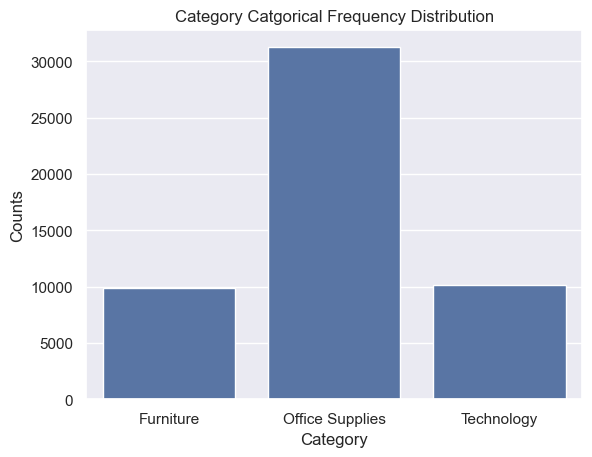

Market Univariate Analysis 
        count  count_percentage
market                         
APAC    11002             21.45
Africa   4587              8.94
Canada    384              0.75
EMEA     5029              9.81
EU      10000             19.50
LATAM   10294             20.07
US       9986             19.47


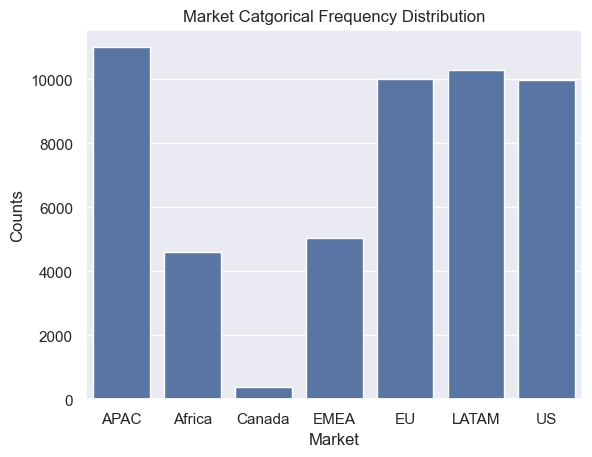

Order_date Univariate Analysis 
            count  count_percentage
order_date                         
2026-07-18  51282             100.0


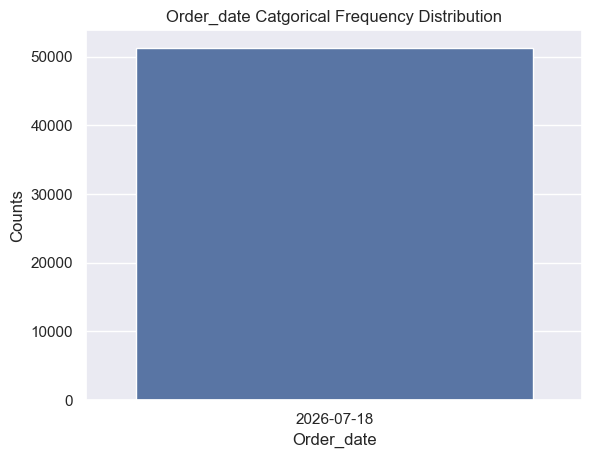

Order_priority Univariate Analysis 
                count  count_percentage
order_priority                         
Critical         3932              7.67
High            15498             30.22
Low              2424              4.73
Medium          29428             57.38


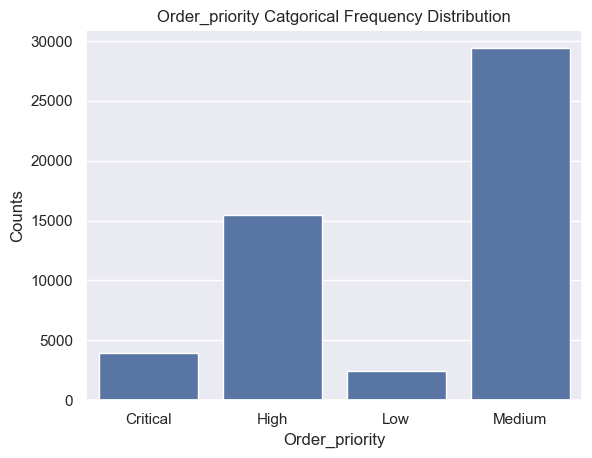

Region Univariate Analysis 
                count  count_percentage
region                                 
Africa           4587              8.94
Canada            384              0.75
Caribbean        1690               3.3
Central         11117             21.68
Central Asia     2048              3.99
EMEA             5029              9.81
East             2847              5.55
North            4785              9.33
North Asia       2338              4.56
Oceania          3487               6.8
South            6645             12.96
Southeast Asia   3129               6.1
West             3196              6.23


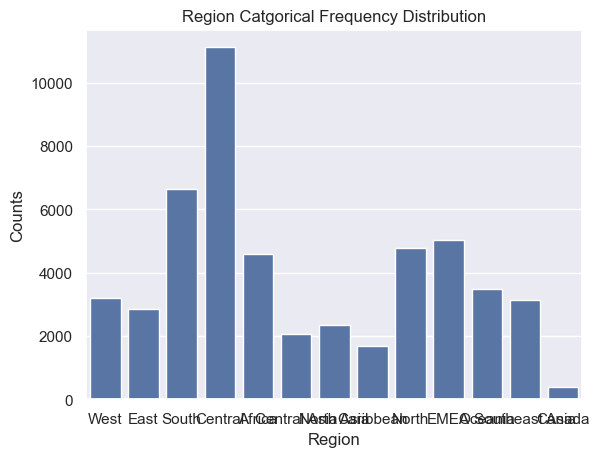

Segment Univariate Analysis 
             count  count_percentage
segment                             
Consumer     26512             51.70
Corporate    15428             30.08
Home Office   9342             18.22


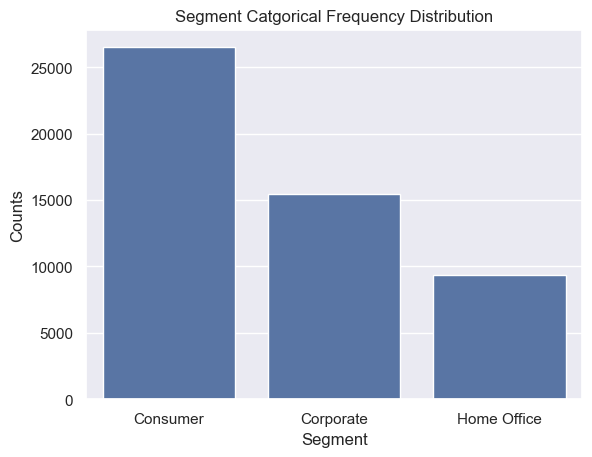

Ship_date Univariate Analysis 
            count  count_percentage
ship_date                          
2026-07-18  51282             100.0


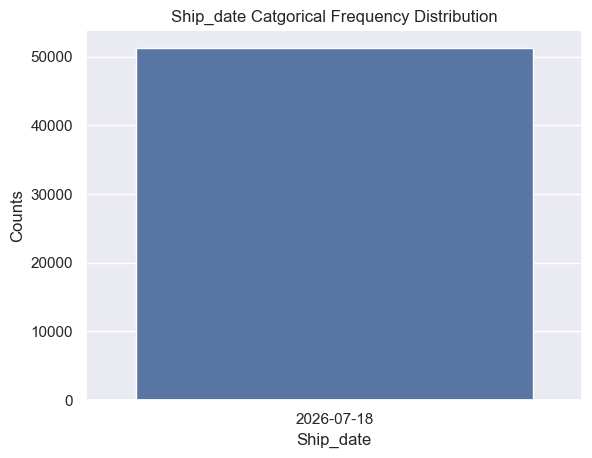

Ship_mode Univariate Analysis 
                count  count_percentage
ship_mode                              
First Class      7503             14.63
Same Day         2699              5.26
Second Class    10308             20.10
Standard Class  30772             60.01


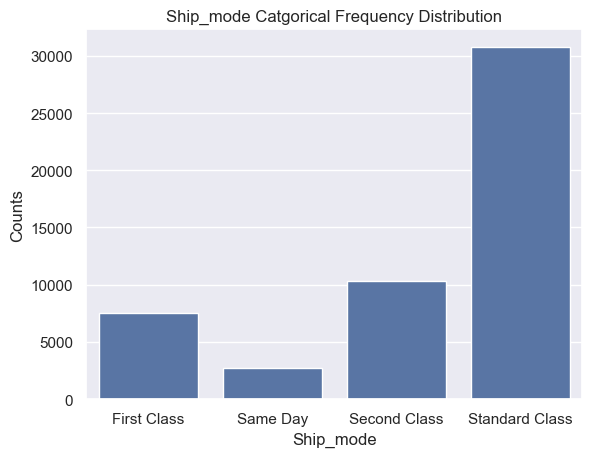

Sub_category Univariate Analysis 
              count  count_percentage
sub_category                         
Accessories    3075              6.00
Appliances     1755              3.42
Art            4880              9.52
Binders        6152             12.00
Bookcases      2411              4.70
Chairs         3434              6.70
Copiers        2223              4.33
Envelopes      2435              4.75
Fasteners      2420              4.72
Furnishings    3170              6.18
Labels         2605              5.08
Machines       1486              2.90
Paper          3535              6.89
Phones         3357              6.55
Storage        5058              9.86
Supplies       2425              4.73
Tables          861              1.68


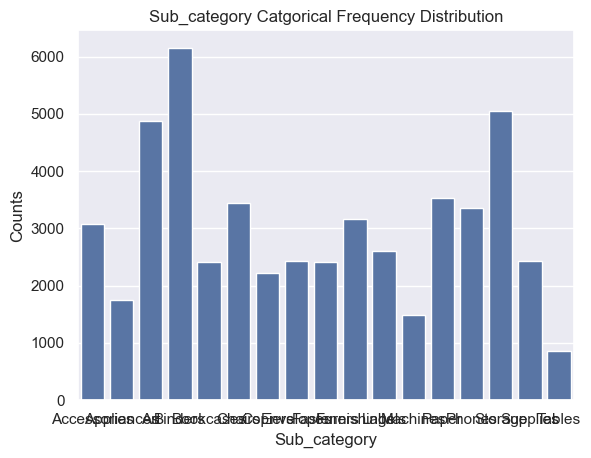

Market2 Univariate Analysis 
               count  count_percentage
market2                               
APAC           11002             21.45
Africa          4587              8.94
EMEA            5029              9.81
EU             10000             19.50
LATAM          10294             20.07
North America  10370             20.22


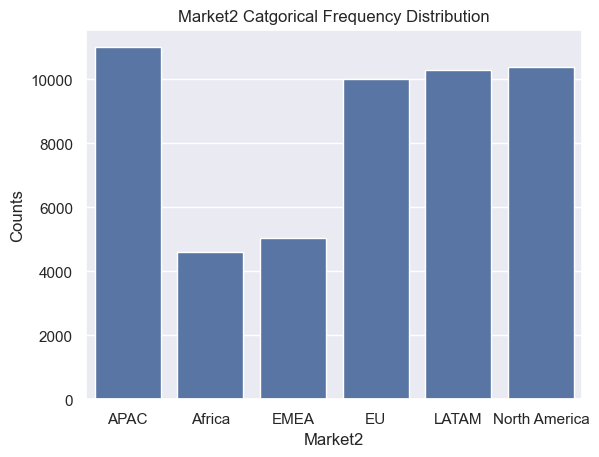

In [174]:
#Choosing the categorical variables with reasonable cardinality

for feature in categorical_features_updated:
    print("="*50)
    print(f"{feature.capitalize()} Univariate Analysis ")
    print("="*50)
    count_feature = data[feature].value_counts().sort_index()
    count_feat_per = round(data[feature].value_counts(normalize = True).sort_index()*100,2)
    feat_df = pd.DataFrame({'count': count_feature,
                           'count_percentage':count_feat_per})
    print(feat_df)
    plt.figure()
    sns.countplot(data = data, x = data[feature])
    plt.xlabel(f"{feature.capitalize()}")
    plt.ylabel("Counts")
    plt.title(f"{feature.capitalize()} Catgorical Frequency Distribution")
    plt.show()

<h4>3.a)Which features seem inaccurate and are not useful as categorical “insights” directly?</h4>

The following features are not useful as categroical insights:
- year: the year column has 4 unique values:2011, 2012, 2013 and 2014. Just the providing the year in which the order was placed provides little to no great insight.
- order_date and ship_date: The order_date column has only one value,[2026/7/18], which was imputed in place of zero values in the origibal dataset. With one value in all 51,282 rows, these two columns have no significance.
- market2: This is a redundant column which has almost the same unique values as market. In the market column 'North America' is split into 'United States' and 'Canada' and thus provides better values than market2 column.
- city, country, customer_id, customer_name, order_id, product_id, product_name, row_id, state: These columns have very high cardinality with values repeating only a handful of times. These provides no great insight as a categorical variable.

In [169]:
for index, cat in enumerate(categorical_features):
    print(index,"{} unique values:".format(cat.capitalize()),data[cat].unique().size)

0 Category unique values: 3
1 City unique values: 3636
2 Country unique values: 147
3 Customer_id unique values: 4873
4 Customer_name unique values: 795
5 Market unique values: 7
6 Order_date unique values: 1
7 Order_id unique values: 25032
8 Order_priority unique values: 4
9 Product_id unique values: 10292
10 Product_name unique values: 3788
11 Region unique values: 13
12 Row_id unique values: 51282
13 Segment unique values: 3
14 Ship_date unique values: 1
15 Ship_mode unique values: 4
16 State unique values: 1094
17 Sub_category unique values: 17
18 Market2 unique values: 6


In [168]:
data["city"].unique().size

3636

<h4>3.b)What’s the issue with treating Customer? Name as a categorical feature for modeling?</h4>

The customer_name column also suffers from high cardinality and thus not very useful for direct univariate plotting.

In [41]:
print(data["customer_name"].unique())

<StringArray>
['Lycoris Saunders',    'Mark Van Huff',     'Chad Sievert',
   'Arthur Prichep',     'Jeremy Farry',    'William Brown',
     'Joseph Airdo',     'Susan Pistek',        'Rob Lucas',
 'Katherine Ducich',
 ...
       'Sung Chung',       'Beth Paige',       'Jack Garza',
   'Michael Oakman',  'Ritsa Hightower',       'Toby Gnade',
      'Emily Burns',   'Troy Blackwell',       'Evan Henry',
       'Tony Sayre']
Length: 795, dtype: string


<h4>3.c) Is the Category distribution balanced or skewed? Give a 1-line reason.</h4>

The category distribution is skewed. Approximately 60% of the data is dominated by 'Office Supplies'

In [45]:
data["category"].value_counts(normalize = True).sort_index()*100

category
Furniture          19.258219
Office Supplies    60.966811
Technology         19.774970
Name: proportion, dtype: float64

<h4>3.d) In Country, does one country dominate strongly? What does that imply about
geographic bias?</h4>

- Yes, as can be seen the United States comprises of approximately 20% of the data. 
- It implies that the datset is heavily biased towards US consumer patterns and economic conditions. Any analytical insights or predictive models trained on this data will be highly optimized for the US market, meaning they may not generalize well or accurately predict customer behavior, shipping timelines, or profitability in smaller, less-represented countries. 

country
United States         19.472719
Australia              5.532156
France                 5.512656
Mexico                 5.155805
Germany                4.026754
China                  3.666004
United Kingdom         3.184353
Brazil                 3.118053
India                  3.032253
Indonesia              2.710503
Turkey                 2.687103
Italy                  2.160602
Nigeria                1.764752
Spain                  1.675052
Dominican Republic     1.446901
El Salvador            1.435201
Cuba                   1.411801
Honduras               1.390351
Philippines            1.327951
New Zealand            1.224601
Name: proportion, dtype: Float64


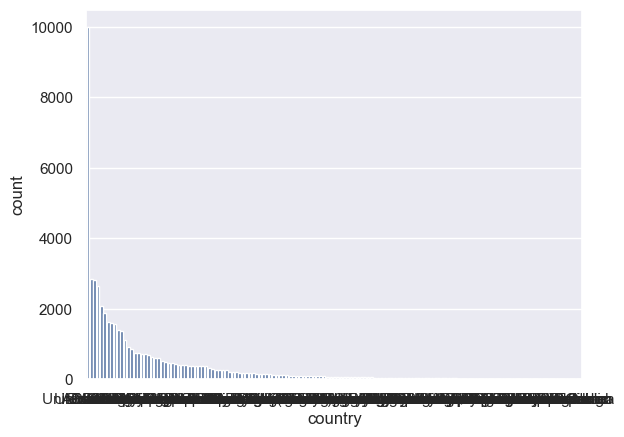

In [58]:
print(data["country"].value_counts(normalize = True).sort_values(ascending = False).head(20)*100)
plt.figure()
sns.countplot(data = data, x = 'country',order = data["country"].value_counts().index)
plt.show()

<h4>3.e)Is the City dataset concentrated in a few cities or spread out?</h4>

The city column is highly spread out with the top most values only accounting for 1-2% of the data. 

city
New York City    1.782302
Los Angeles      1.456651
Philadelphia     1.047151
San Francisco    0.992551
Santo Domingo    0.863851
Manila           0.842401
Seattle          0.826801
Houston          0.735151
Tegucigalpa      0.705901
Jakarta          0.657151
Managua          0.655201
Lagos            0.649351
Chicago          0.612301
Istanbul         0.612301
Mexico City      0.585001
Bangkok          0.559651
London           0.547951
Sydney           0.528451
Cairo              0.4836
Vienna            0.47775
Name: proportion, dtype: Float64


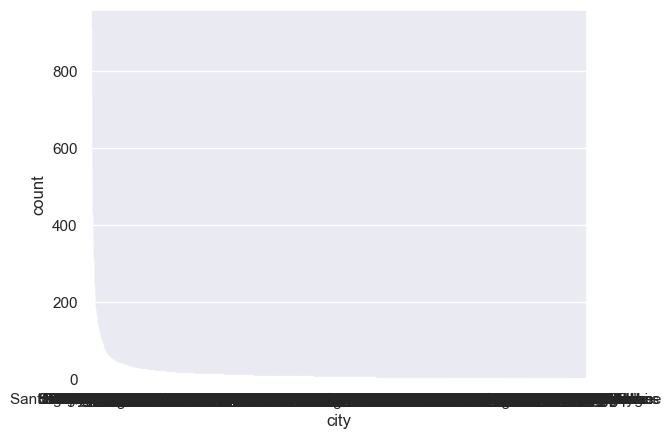

In [57]:
print(data["city"].value_counts(normalize = True).sort_values(ascending = False).head(20)*100)
plt.figure()
sns.countplot(data = data, x = 'city',order = data["city"].value_counts().index)
plt.show()

<h3>4. Perform Bivariate Analysis for numerical-to-numerical features</h3>

<Figure size 640x480 with 0 Axes>

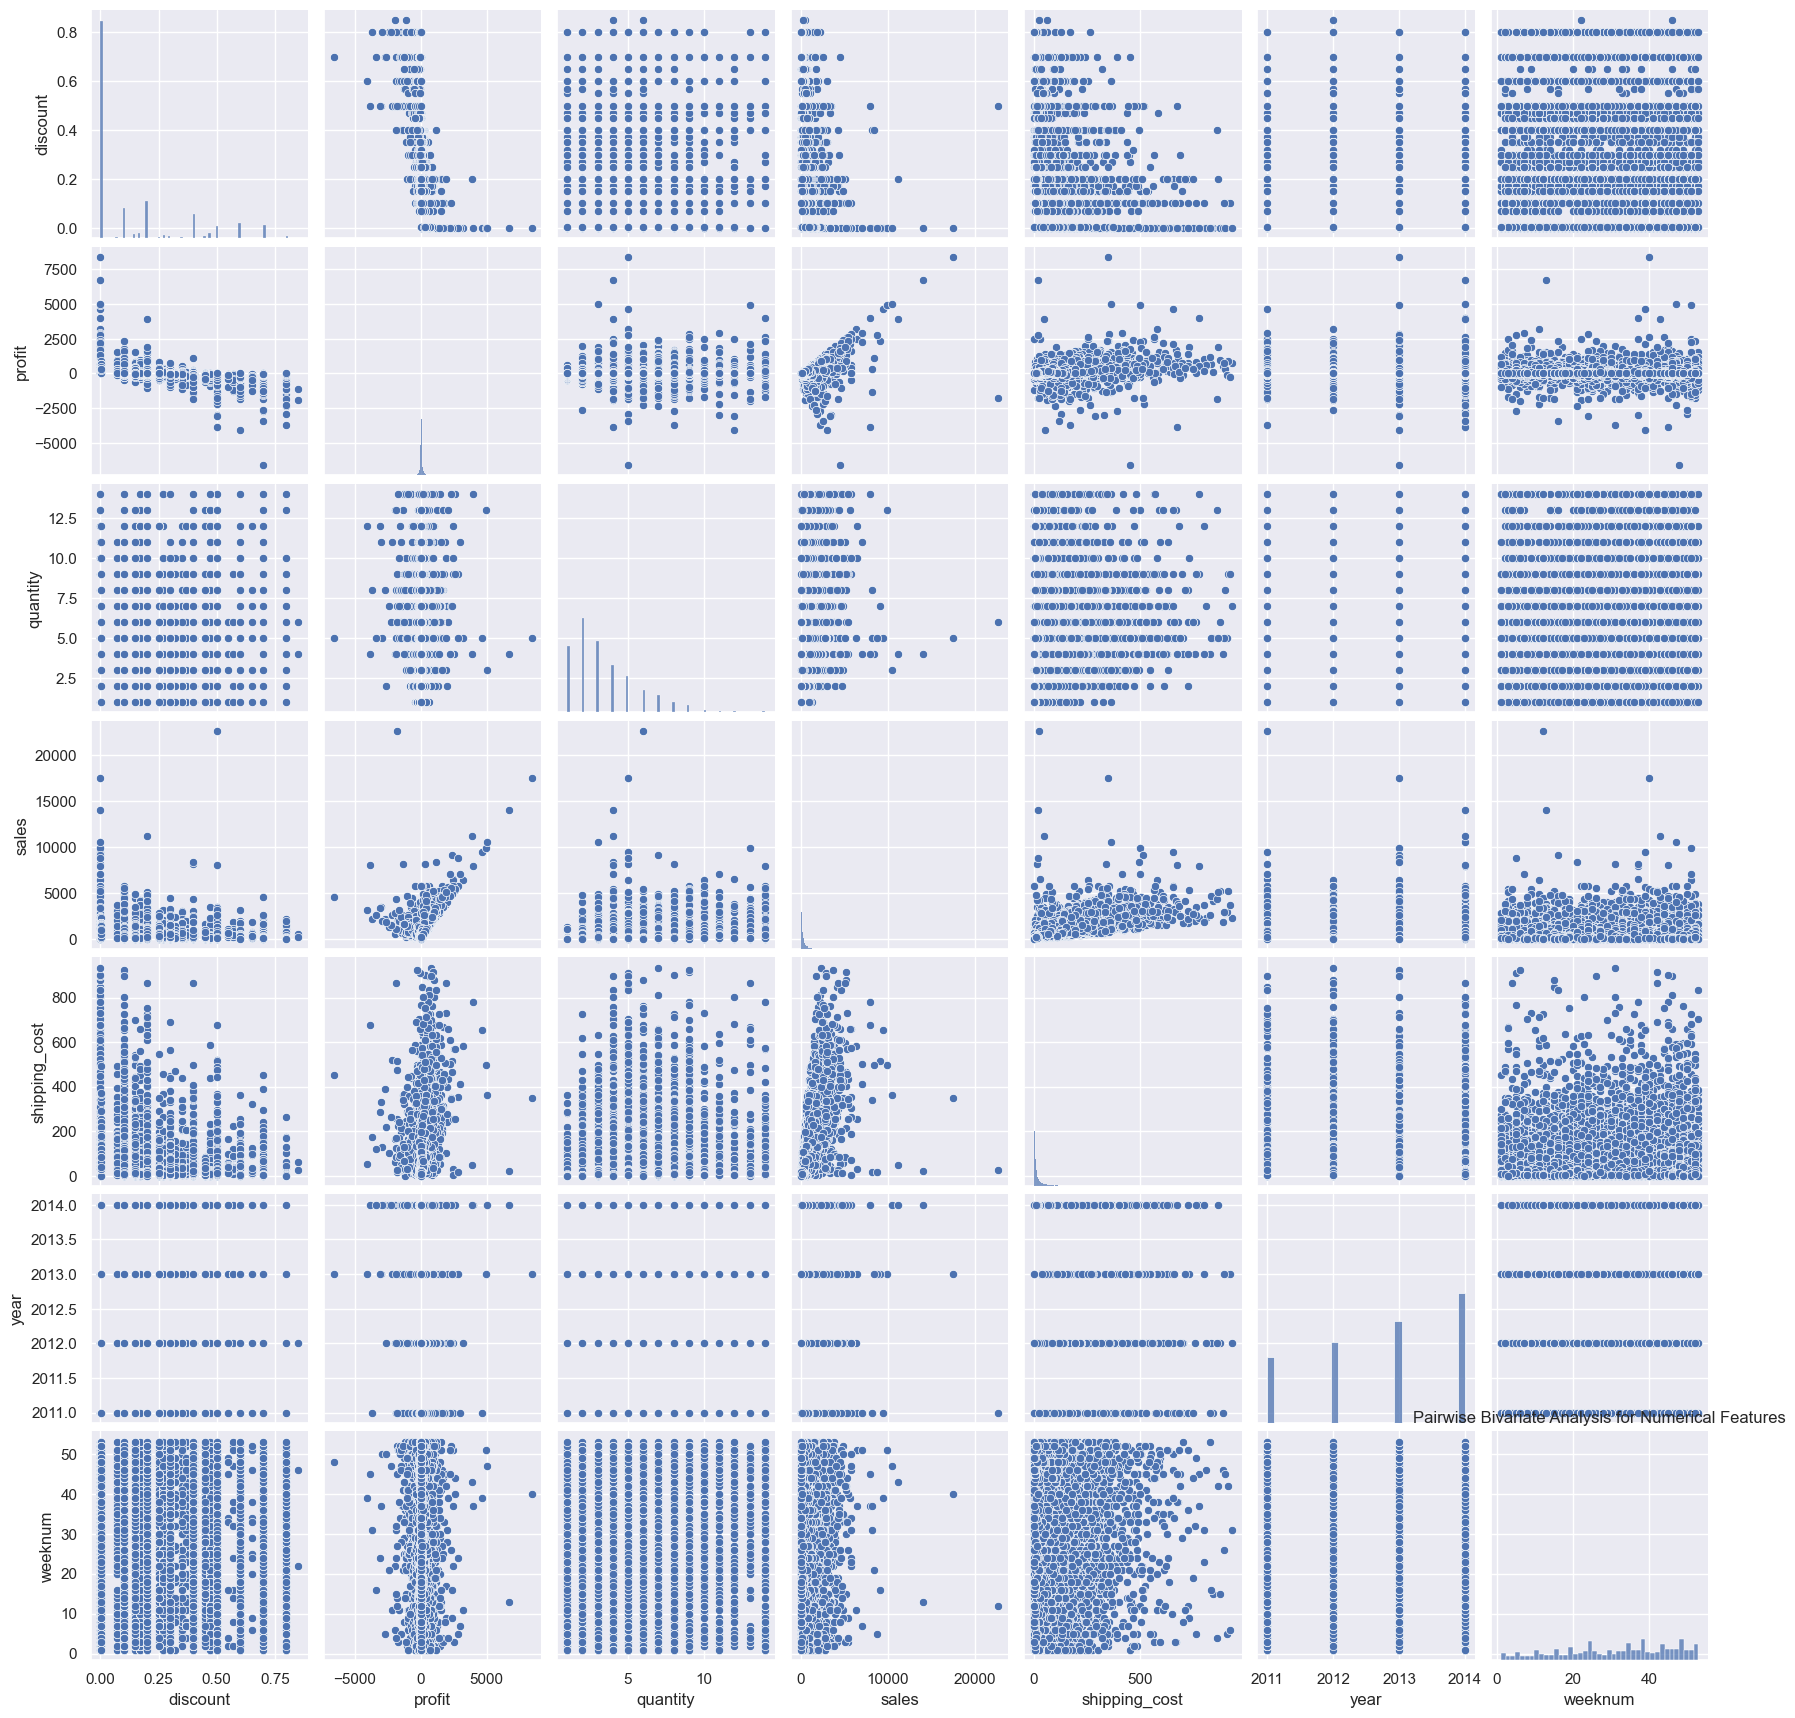

In [60]:
plt.figure()
sns.pairplot(data[numerical_features])
plt.title("Pairwise Bivariate Analysis for Numerical Features")
plt.show()

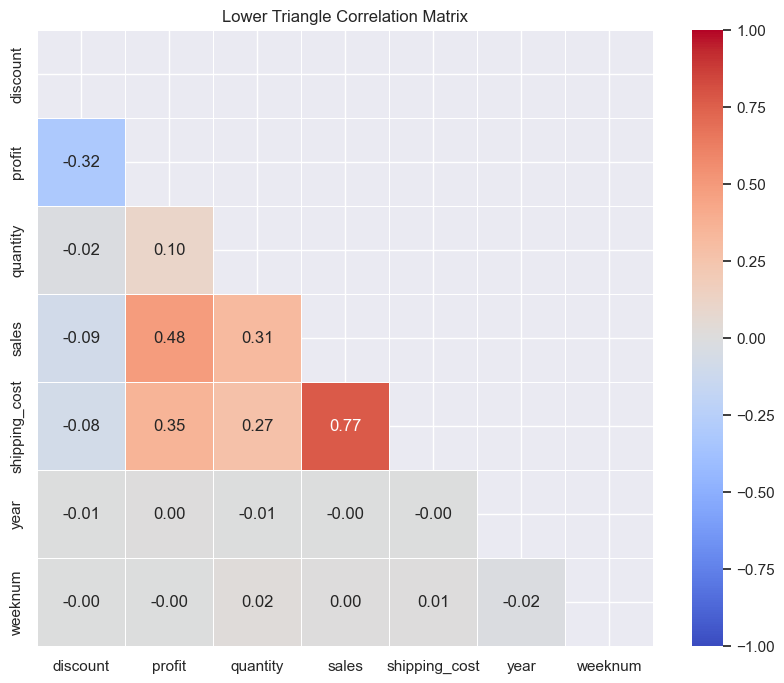

In [63]:
corr = data.select_dtypes(include = np.number).corr()
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    vmin = -1,
    vmax = 1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True
)
plt.title("Lower Triangle Correlation Matrix")
plt.show()

<h4>4.a) Which two features are most strongly correlated?</h4>

The sales and shipping_cost are the most correlated features which implies that as the sales go up the shipping_cost also increases which is intuitively correct. 

<h4>4.b)Also name features that are negatively correlated.</h4> 

The feature negatively correlated are profit and discount. The more the discount the less the profit which again is inutitively correct. 

<h4>4.c) If your goal is to understand profit, which are the most useful next bivariate checks?
Perform them and give clear insights.</h4>

- The most useful next bivariate checks involve analyzing profit against its strongest numerical drivers: sales, shipping_cost, and discount.

- Profit vs. Sales & Shipping Cost: These features exhibit strong positive relationships with profit, showing that larger transaction values scale up absolute margins.

- Profit vs. Discount: This is the most critical check. Discount shares a sharp negative correlation with profit. Plotting this reveals the "Discount Trap"—confirming that when discount rates cross a specific threshold, transactions immediately drop into severe negative profit outliers.

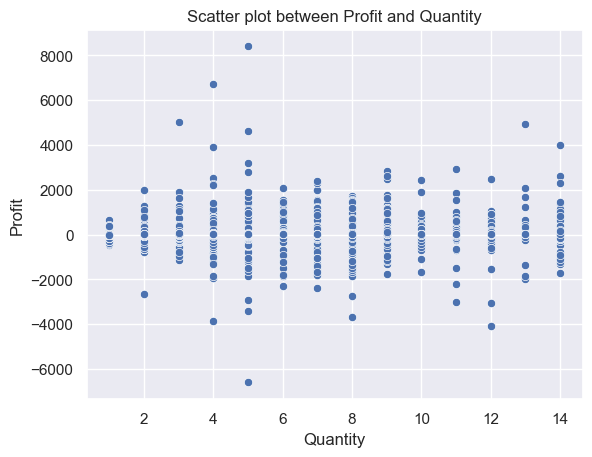

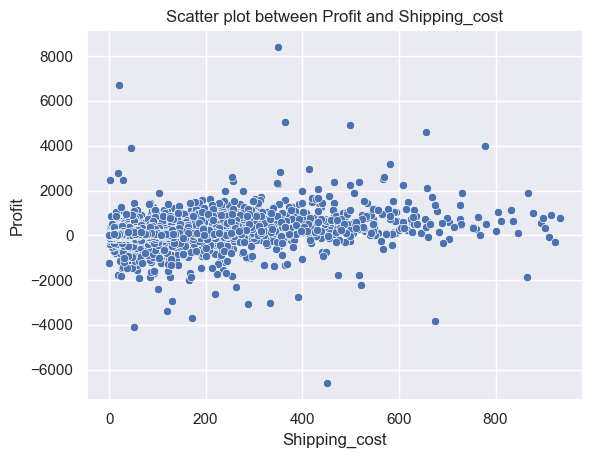

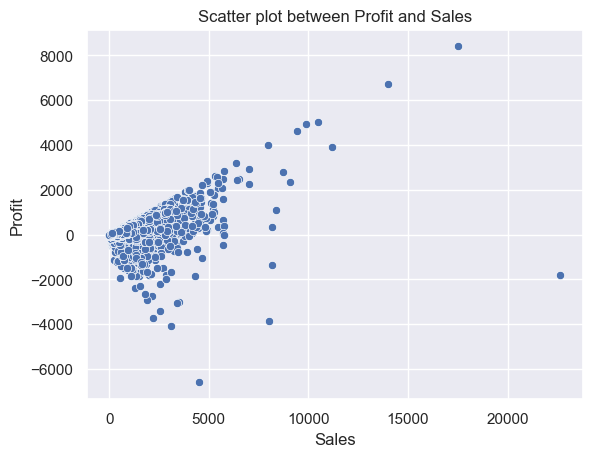

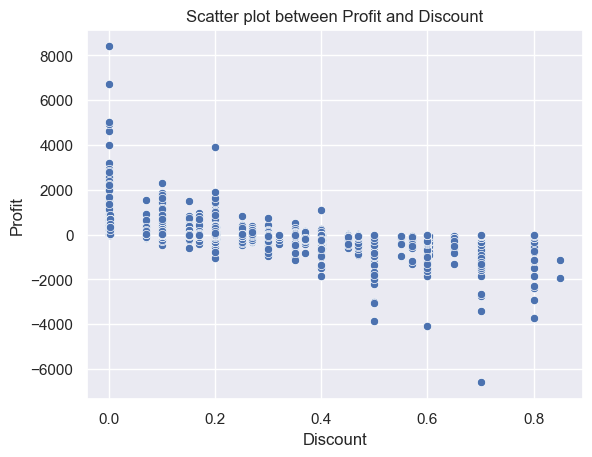

In [107]:
corr_feat = {'shipping_cost', 'sales', 'quantity', 'discount'}
for feat in corr_feat:
    plt.figure()
    sns.scatterplot(data = data, y = 'profit', x = feat)
    plt.title(f"Scatter plot between Profit and {feat.capitalize()}")
    plt.ylabel("Profit")
    plt.xlabel(f"{feat.capitalize()}")
    plt.show()

<h4>4.d) Look for Time Effects Clues. Mention any information you find about the time
relationship with any feature.</h4>


Based on the yearly information provided below, it seems that the mean data for all four years is almost the same. It follows a seasonal pattern with high sales during Q1 and then dips for Q2 and Q3 and then again goes back up for Q4.  

year
2011    251.156959
2012    244.317182
2013    246.831207
2014    245.308460
Name: sales, dtype: float64
year  quarters
2011  Q1          252.792438
      Q2          234.512948
      Q3          250.161013
      Q4          261.246921
2012  Q1          248.440452
      Q2          237.778411
      Q3          248.860905
      Q4          245.011510
2013  Q1          264.393644
      Q2          246.918847
      Q3          230.319058
      Q4          250.013752
2014  Q1          254.387109
      Q2          229.215259
      Q3          249.841760
      Q4          249.569926
Name: sales, dtype: float64


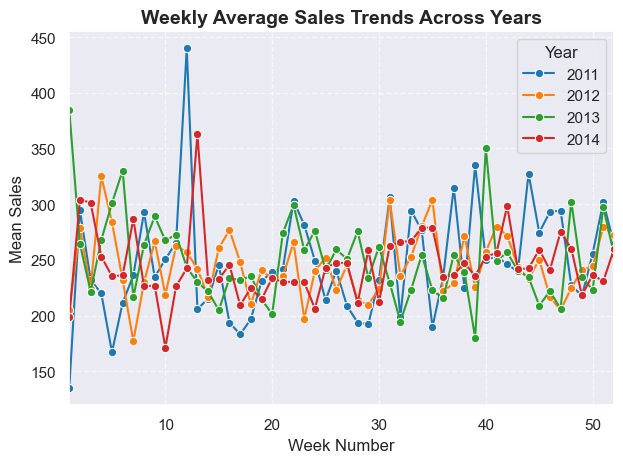

In [104]:
print(data.groupby("year")["sales"].mean())
bins = [1,13,26,39,53]
labels = ['Q1','Q2','Q3','Q4']
data["quarters"] = pd.cut(data['weeknum'], bins = bins, labels = labels, ordered = True)
print(data.groupby(["year",'quarters'],observed = True)["sales"].mean())

df2 = data.groupby(by = ["year","weeknum"])["sales"].mean().reset_index()
plt.figure()
sns.lineplot(data = df2, y = "sales",x = "weeknum",hue = "year", palette = "tab10", marker = "o")
plt.title("Weekly Average Sales Trends Across Years", fontsize=14, fontweight='bold')
plt.xlabel("Week Number", fontsize=12)
plt.ylabel("Mean Sales", fontsize=12)
plt.xlim(1, 52)  # Limits x-axis to standard week ranges
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Year")

plt.tight_layout()
plt.show()



<h3>5. Perform Bi-variate Analysis for categorical to numerical features</h3>

In [ ]:
# Use this to perform analysis for all categorical variables
# for catf in categorical_features:
#     for numf in numerical_features:
#         print("="*50)
#         print("Bivariate Analysis between {} and {}".format(catf.capitalize(),numf.capitalize()))
#         print("="*50)
#         plt.figure()
#         sns.boxplot(data = data, x = catf, y = numf)
#         plt.title("Bivariate Analysis between {} and {}".format(catf.capitalize(),numf.capitalize()))
#         plt.xlabel(catf.capitalize())
#         plt.ylabel(numf.capitalize())
#         plt.show()

Bivariate Analysis between Category and Discount


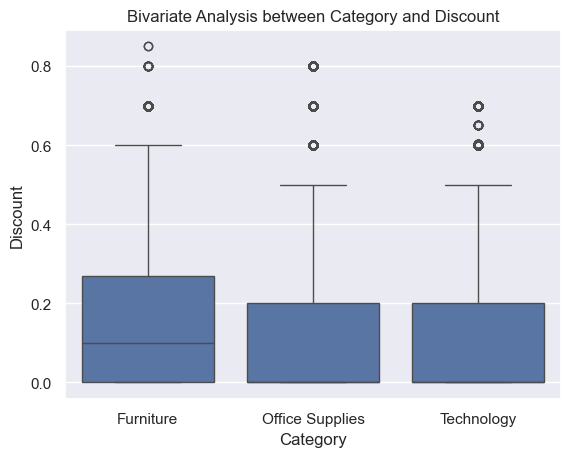

Bivariate Analysis between Category and Profit


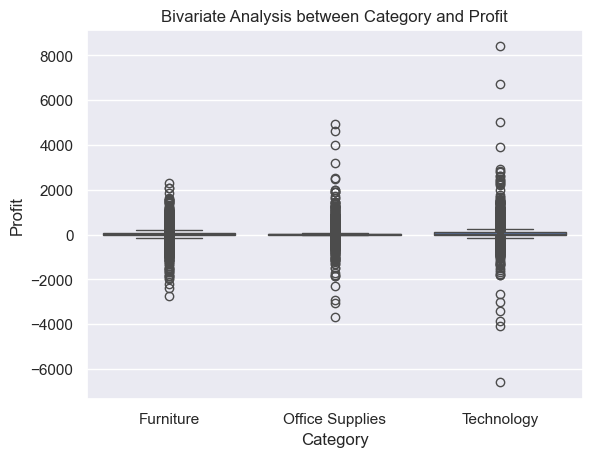

Bivariate Analysis between Category and Quantity


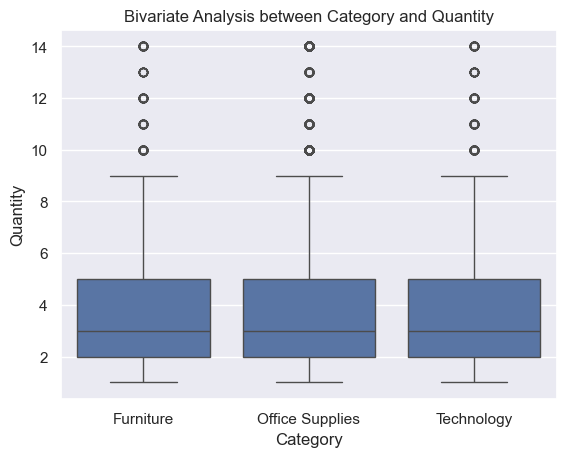

Bivariate Analysis between Category and Sales


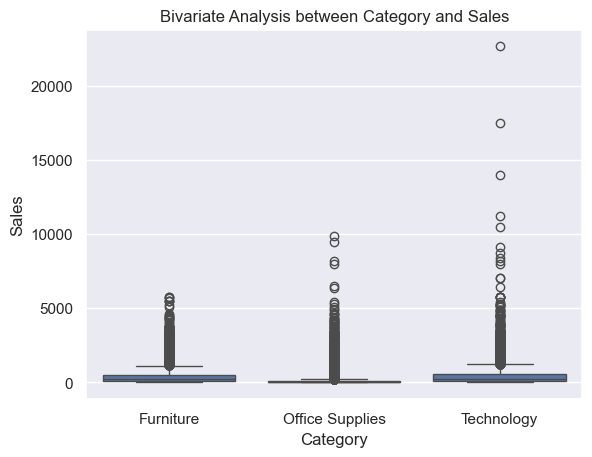

Bivariate Analysis between Category and Shipping_cost


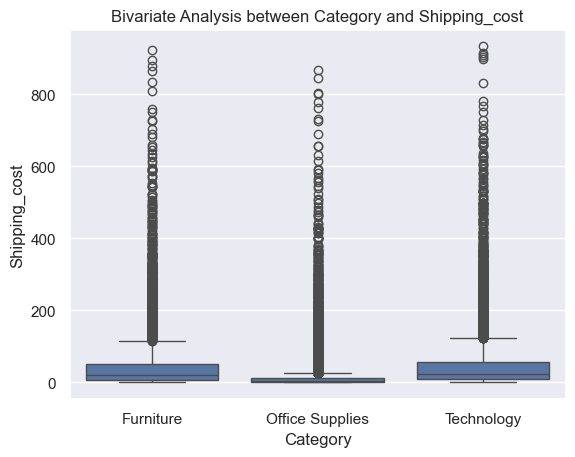

Bivariate Analysis between Category and Year


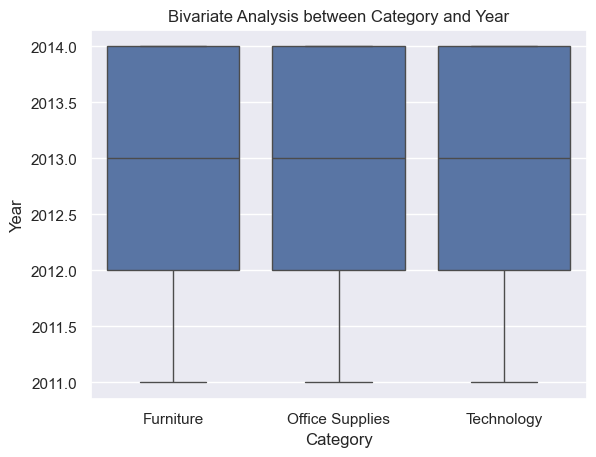

Bivariate Analysis between Category and Weeknum


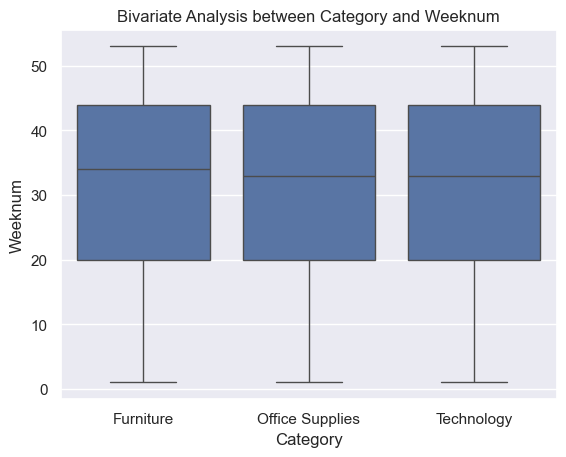

Bivariate Analysis between Market and Discount


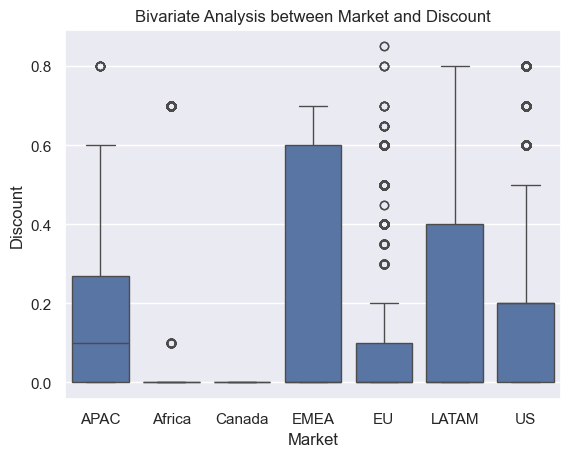

Bivariate Analysis between Market and Profit


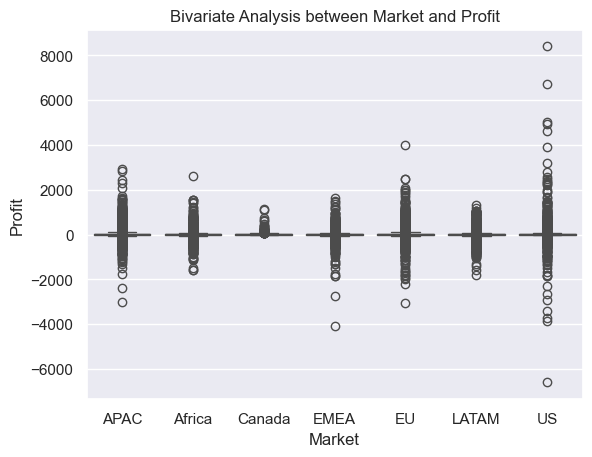

Bivariate Analysis between Market and Quantity


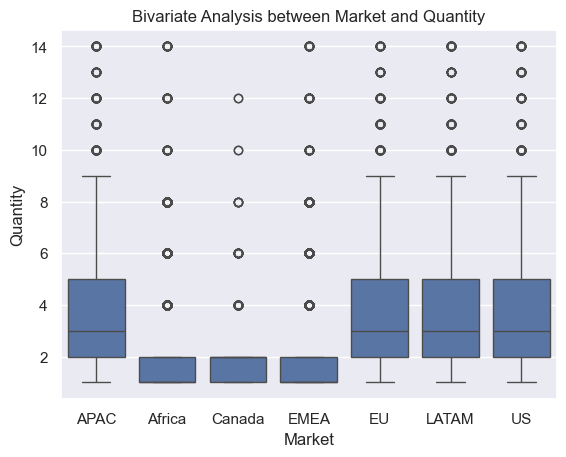

Bivariate Analysis between Market and Sales


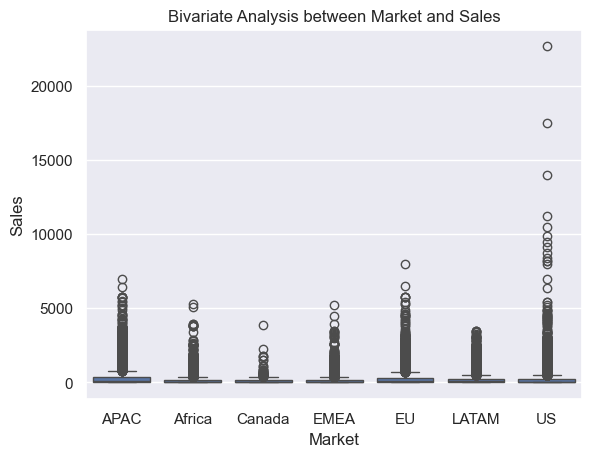

Bivariate Analysis between Market and Shipping_cost


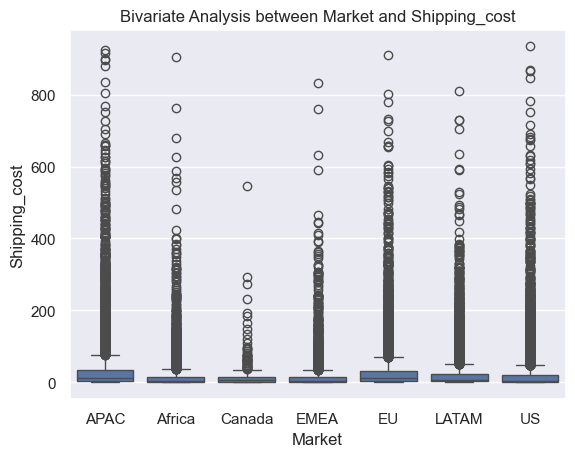

Bivariate Analysis between Market and Year


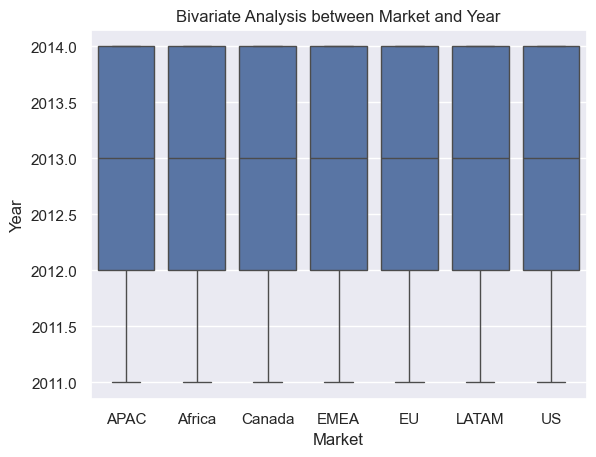

Bivariate Analysis between Market and Weeknum


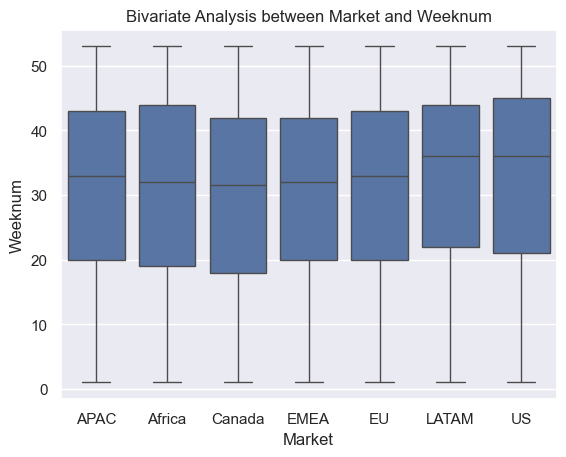

Bivariate Analysis between Order_date and Discount


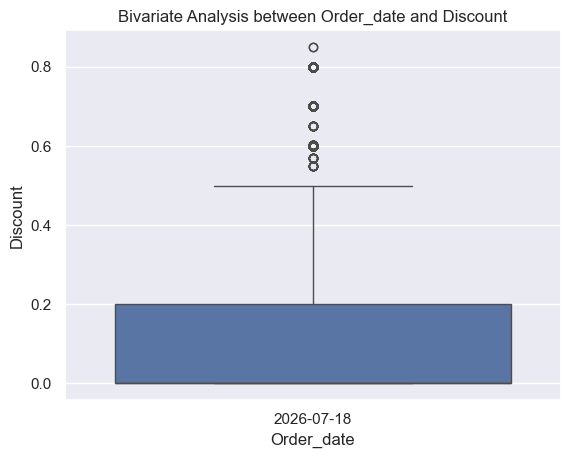

Bivariate Analysis between Order_date and Profit


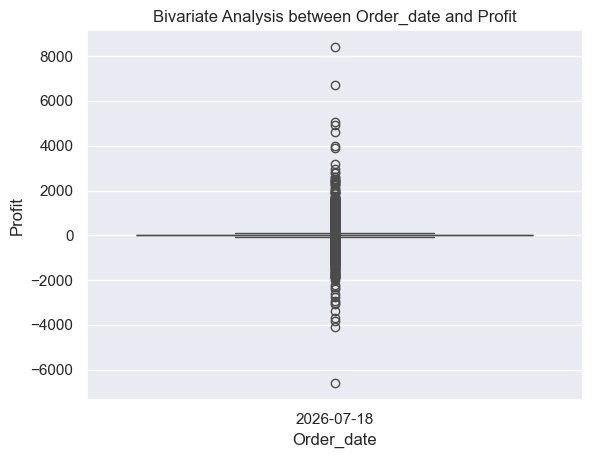

Bivariate Analysis between Order_date and Quantity


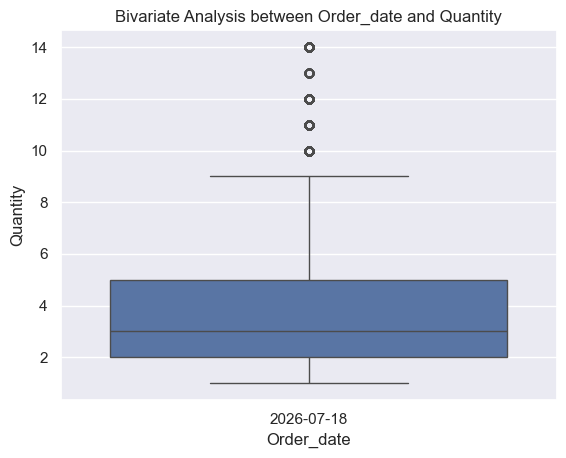

Bivariate Analysis between Order_date and Sales


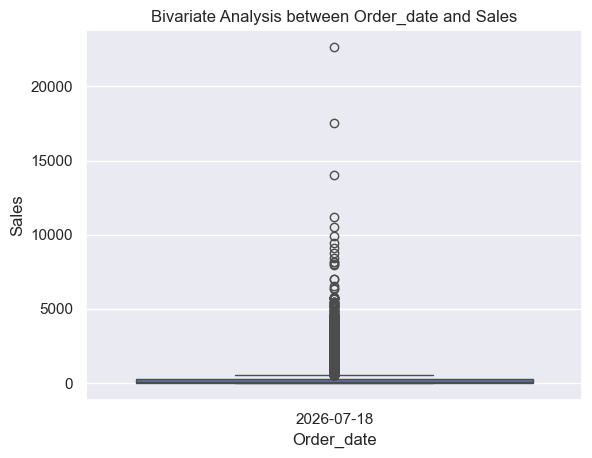

Bivariate Analysis between Order_date and Shipping_cost


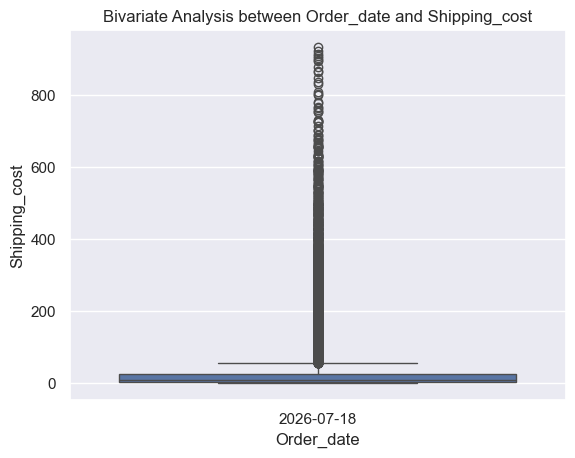

Bivariate Analysis between Order_date and Year


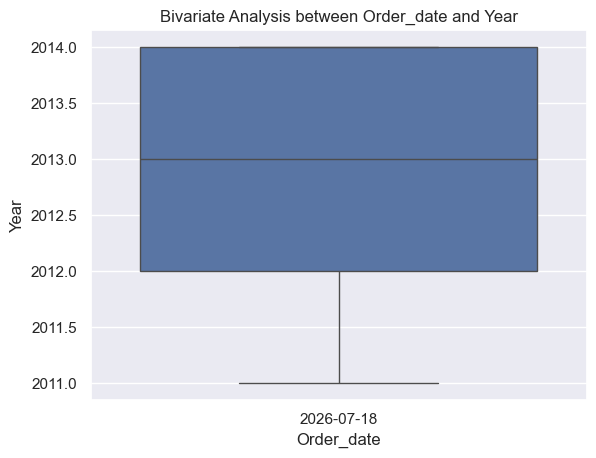

Bivariate Analysis between Order_date and Weeknum


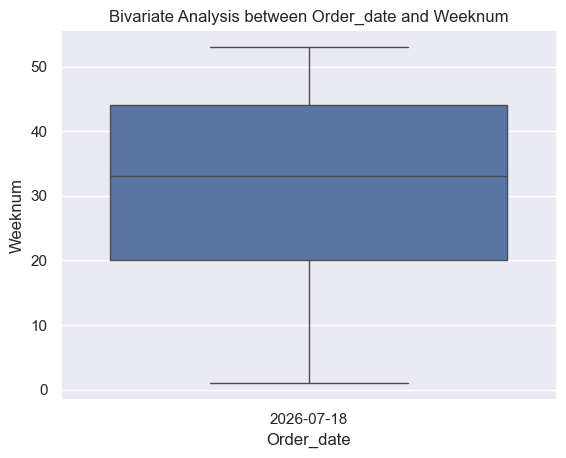

Bivariate Analysis between Order_priority and Discount


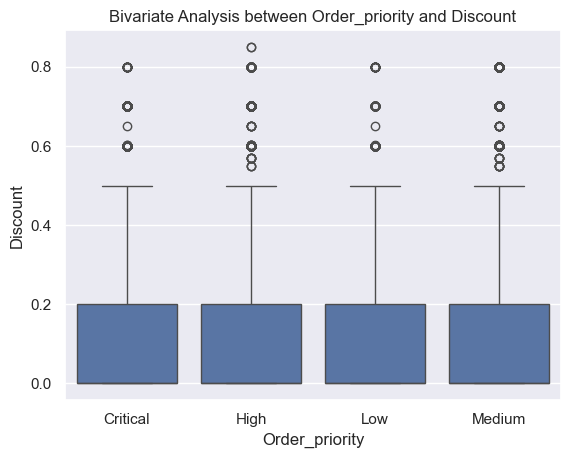

Bivariate Analysis between Order_priority and Profit


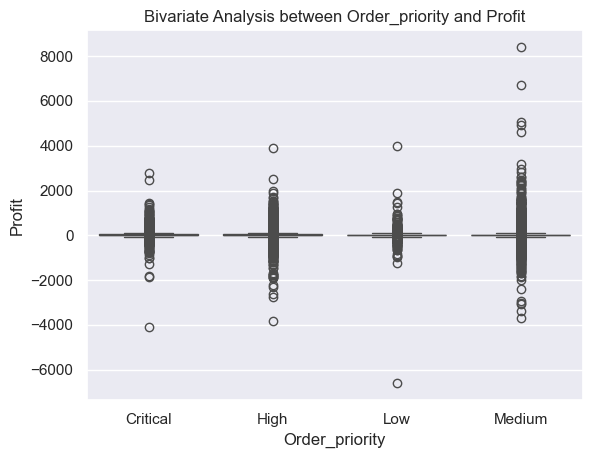

Bivariate Analysis between Order_priority and Quantity


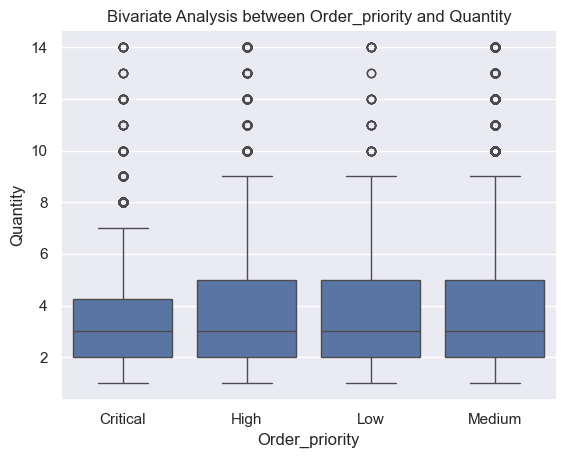

Bivariate Analysis between Order_priority and Sales


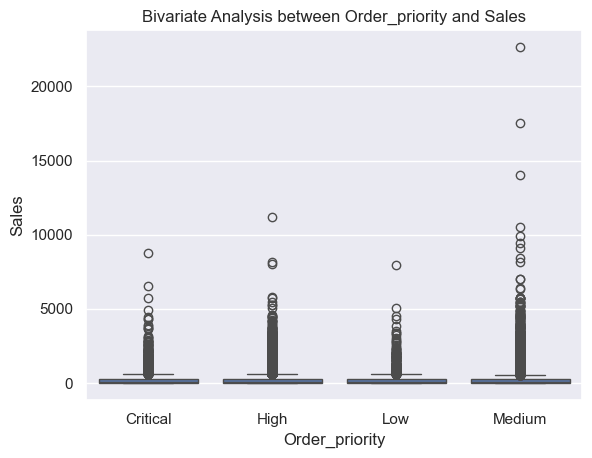

Bivariate Analysis between Order_priority and Shipping_cost


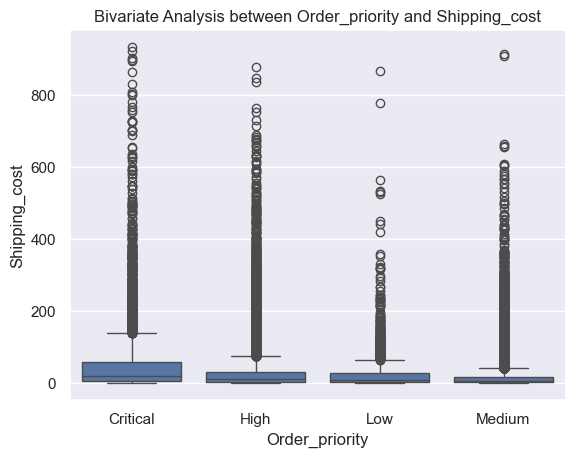

Bivariate Analysis between Order_priority and Year


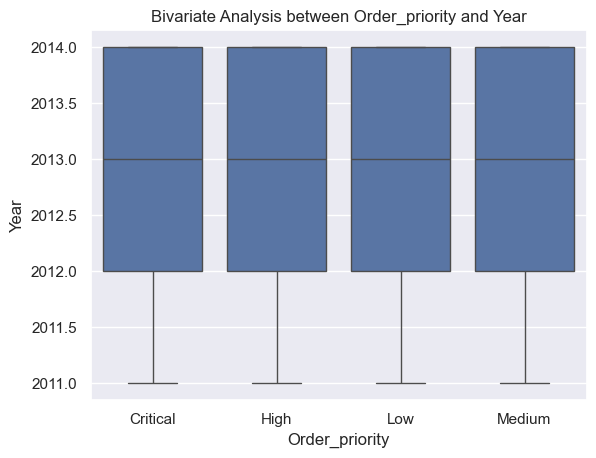

Bivariate Analysis between Order_priority and Weeknum


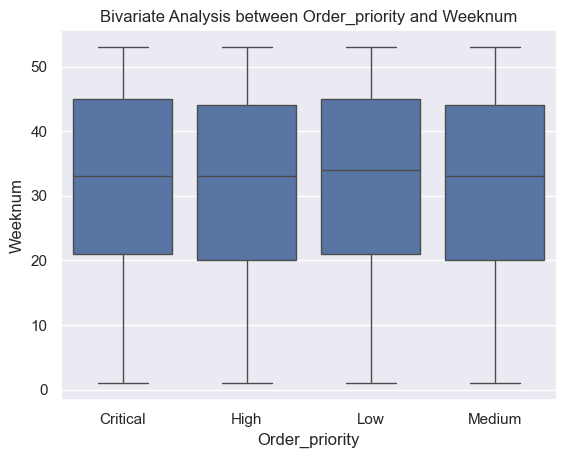

Bivariate Analysis between Region and Discount


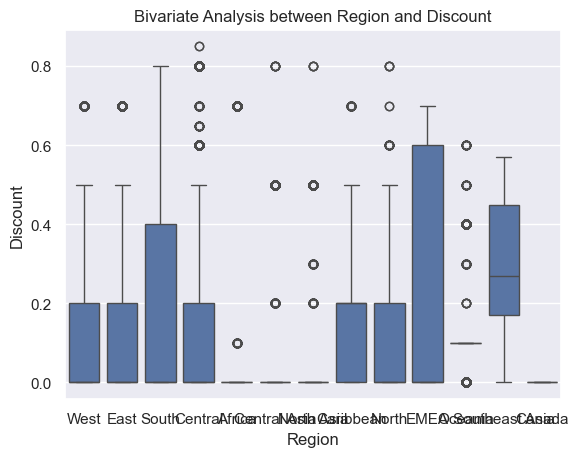

Bivariate Analysis between Region and Profit


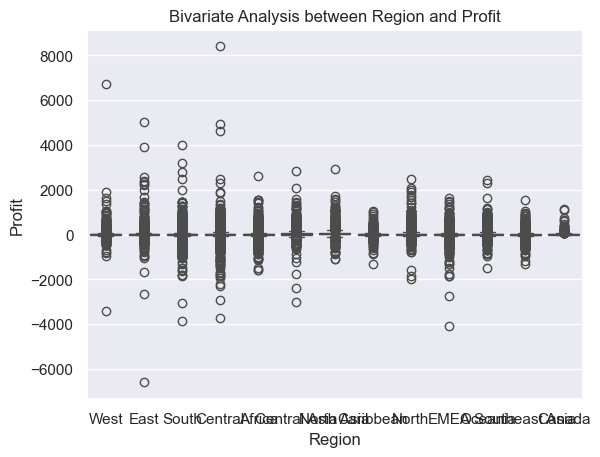

Bivariate Analysis between Region and Quantity


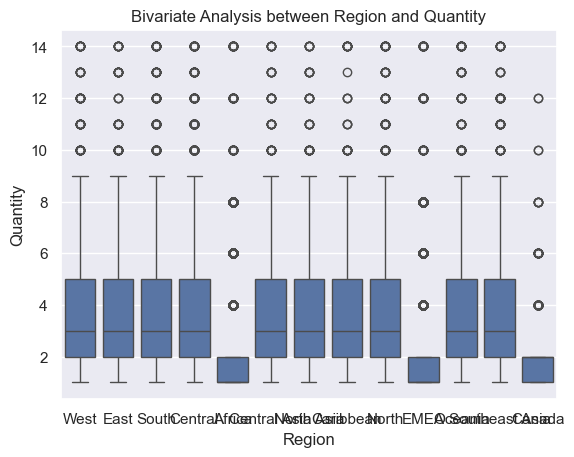

Bivariate Analysis between Region and Sales


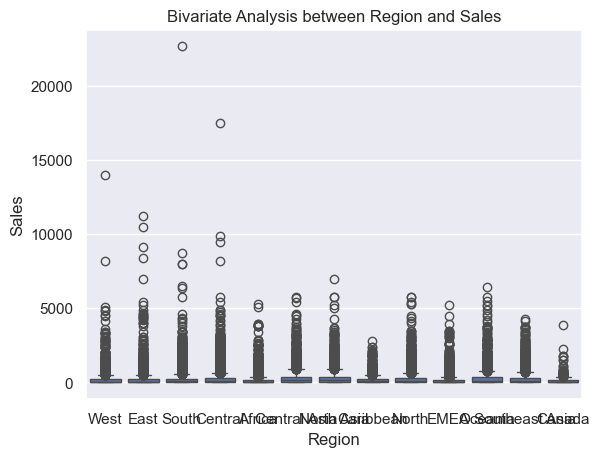

Bivariate Analysis between Region and Shipping_cost


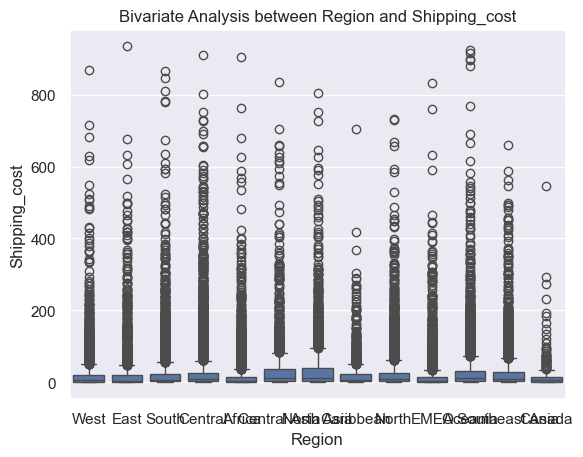

Bivariate Analysis between Region and Year


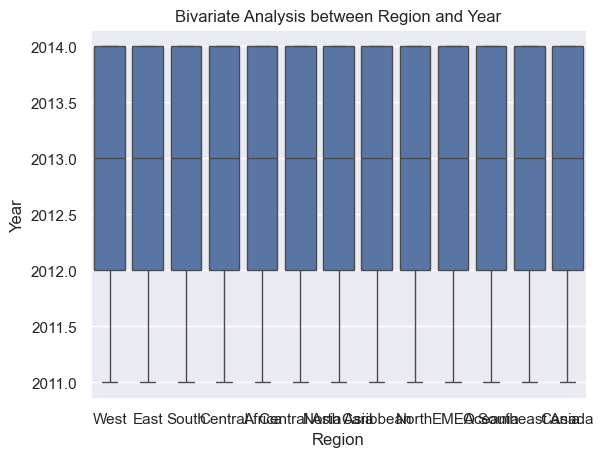

Bivariate Analysis between Region and Weeknum


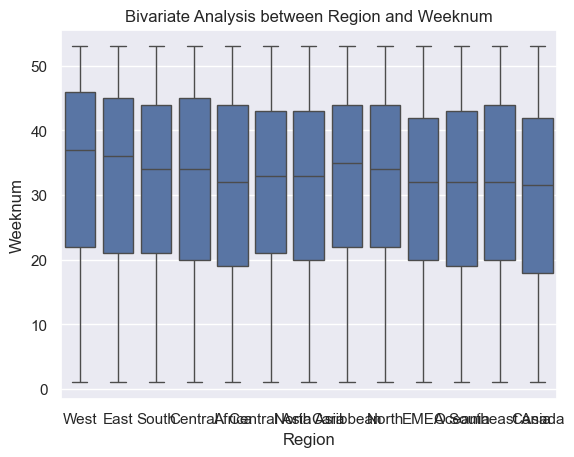

Bivariate Analysis between Segment and Discount


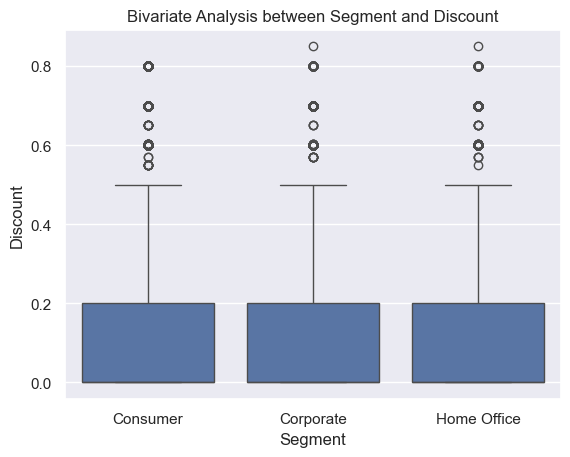

Bivariate Analysis between Segment and Profit


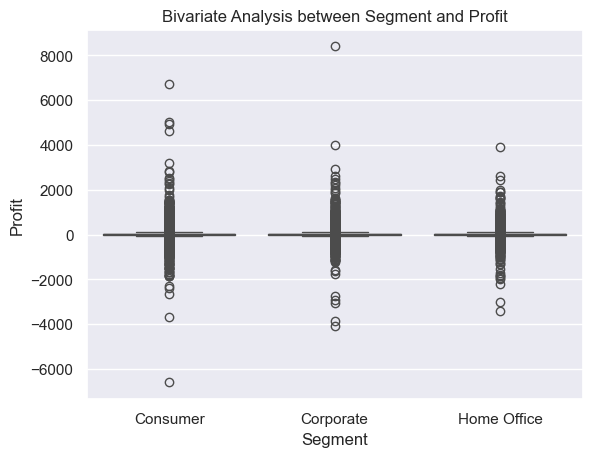

Bivariate Analysis between Segment and Quantity


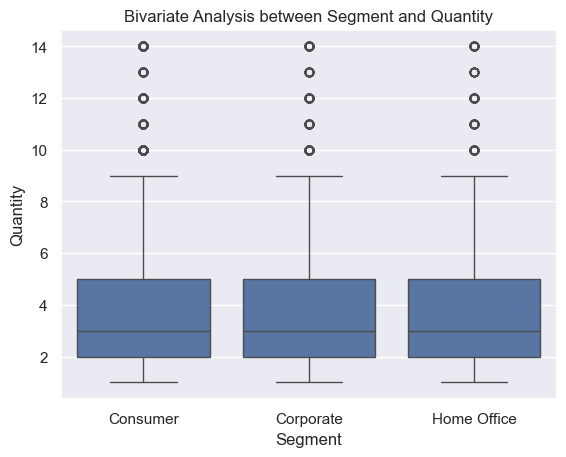

Bivariate Analysis between Segment and Sales


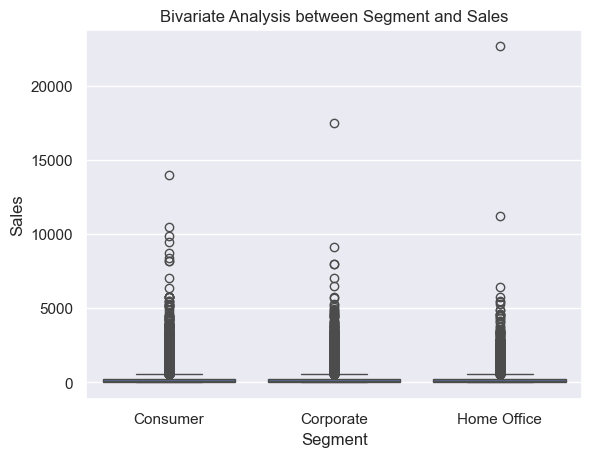

Bivariate Analysis between Segment and Shipping_cost


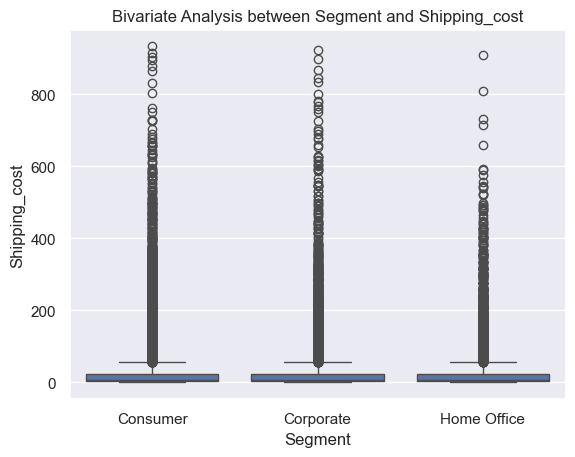

Bivariate Analysis between Segment and Year


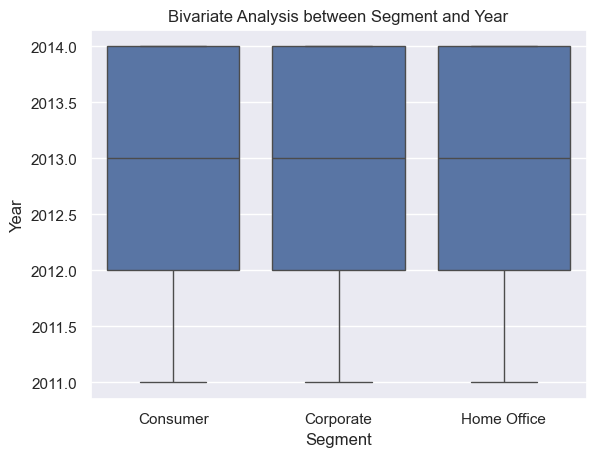

Bivariate Analysis between Segment and Weeknum


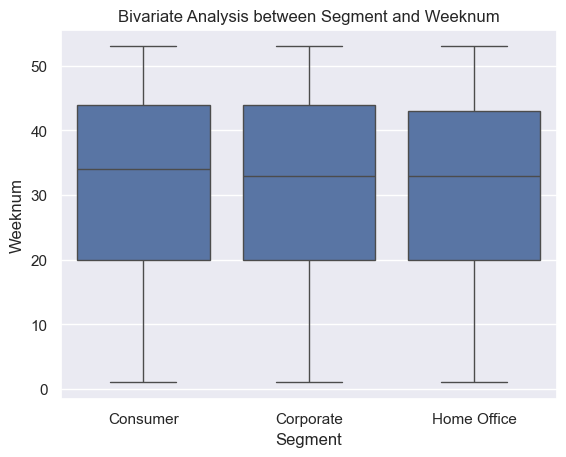

Bivariate Analysis between Ship_date and Discount


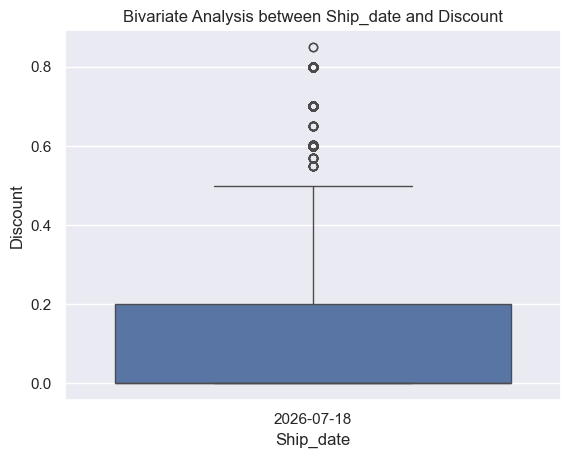

Bivariate Analysis between Ship_date and Profit


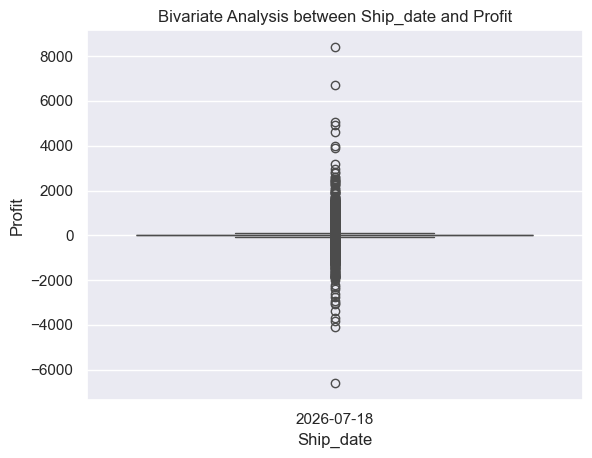

Bivariate Analysis between Ship_date and Quantity


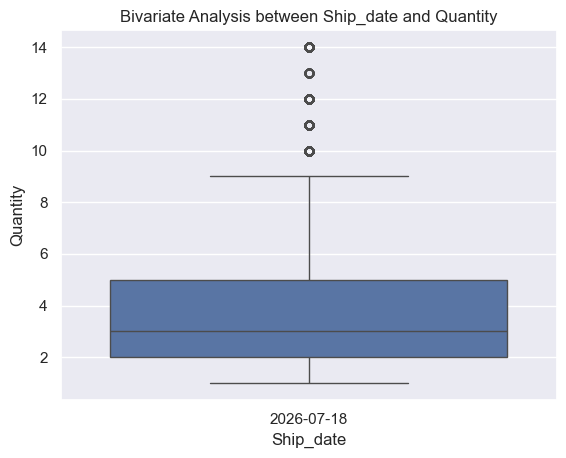

Bivariate Analysis between Ship_date and Sales


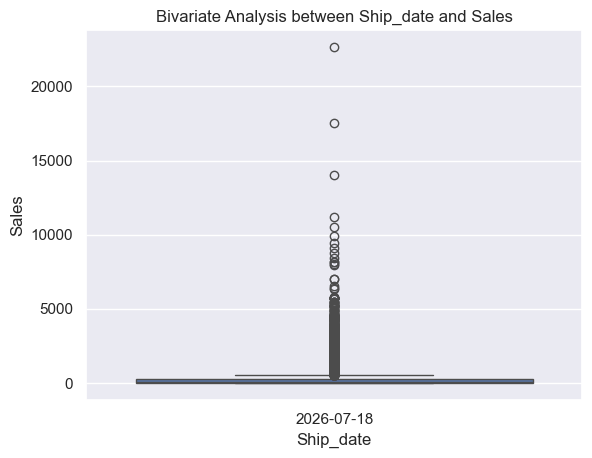

Bivariate Analysis between Ship_date and Shipping_cost


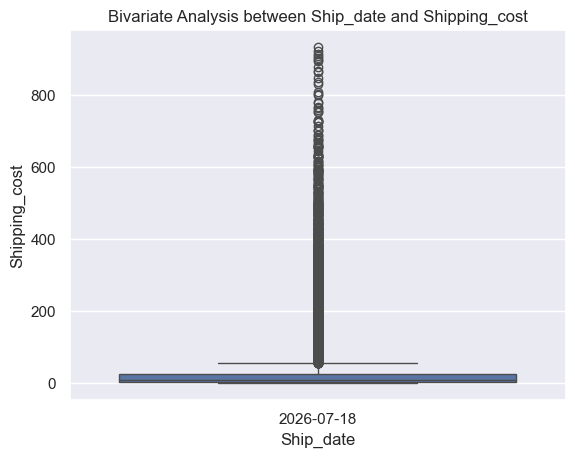

Bivariate Analysis between Ship_date and Year


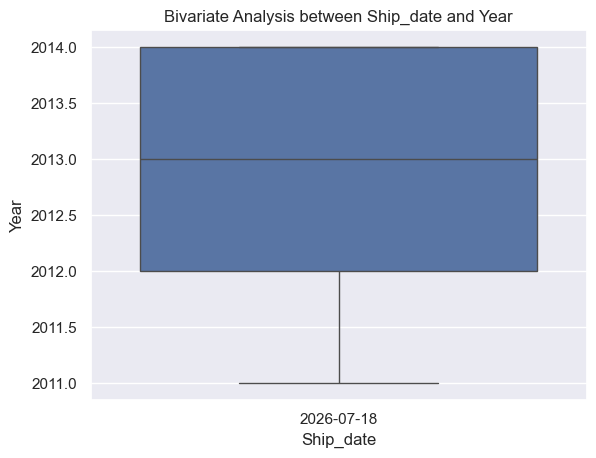

Bivariate Analysis between Ship_date and Weeknum


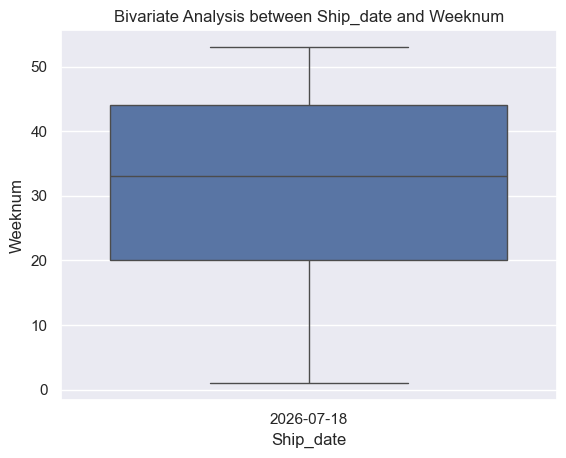

Bivariate Analysis between Ship_mode and Discount


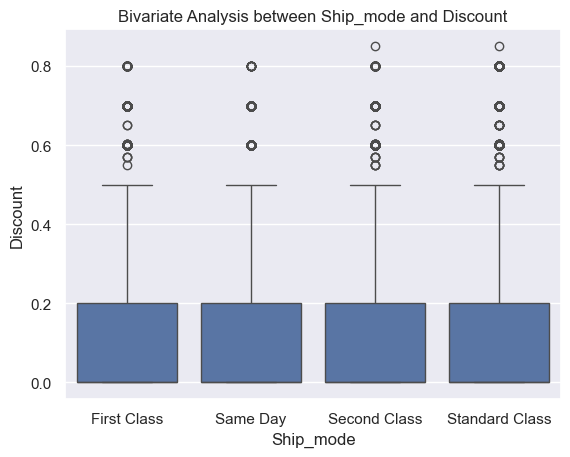

Bivariate Analysis between Ship_mode and Profit


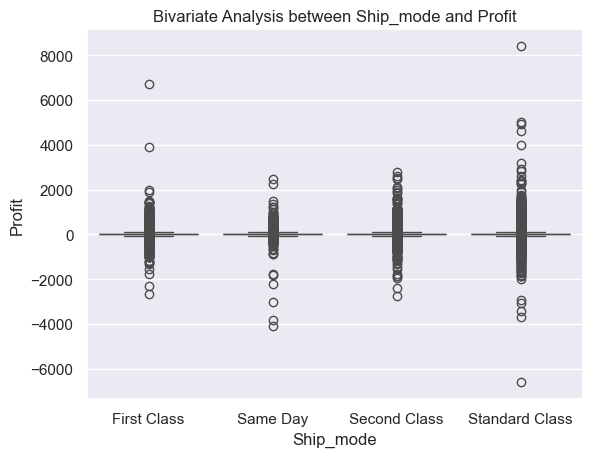

Bivariate Analysis between Ship_mode and Quantity


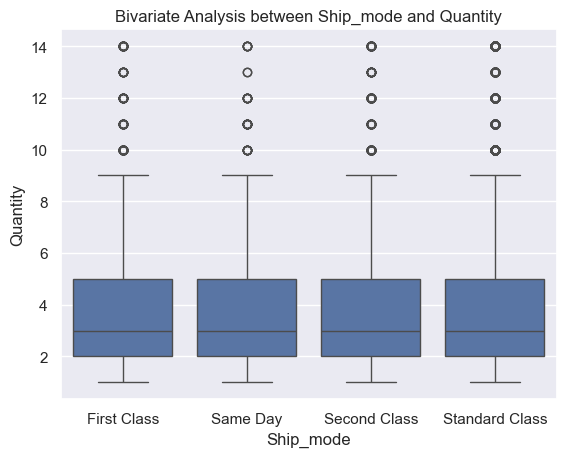

Bivariate Analysis between Ship_mode and Sales


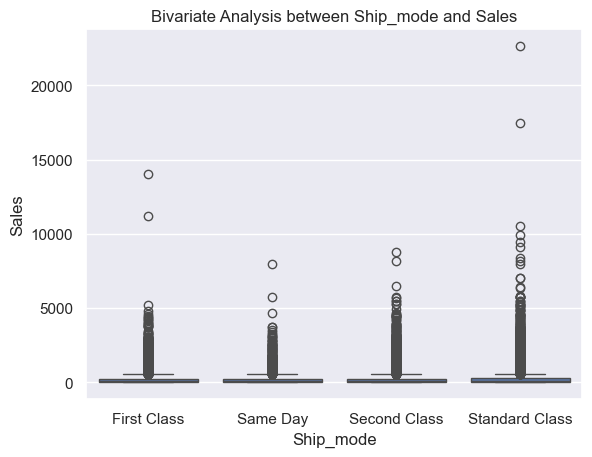

Bivariate Analysis between Ship_mode and Shipping_cost


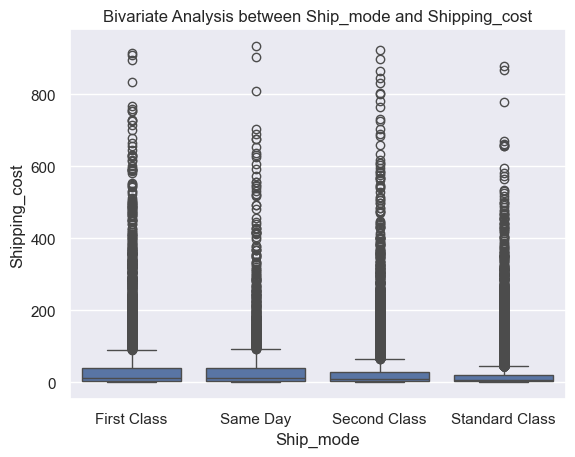

Bivariate Analysis between Ship_mode and Year


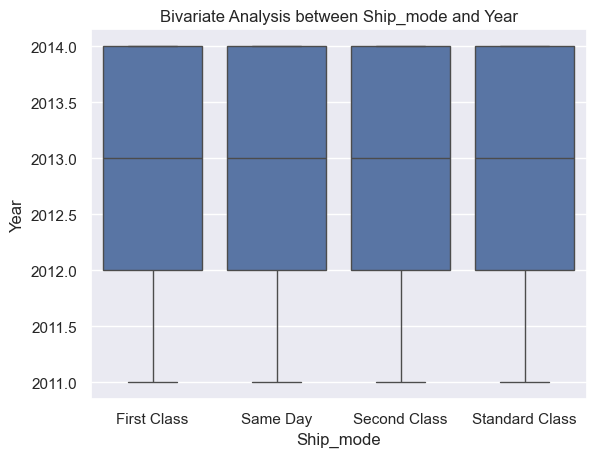

Bivariate Analysis between Ship_mode and Weeknum


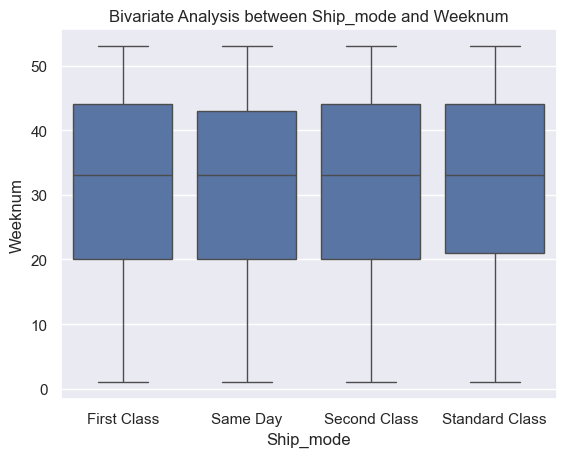

Bivariate Analysis between Sub_category and Discount


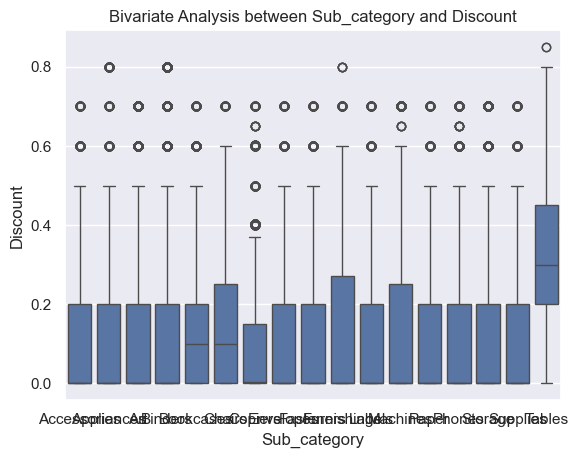

Bivariate Analysis between Sub_category and Profit


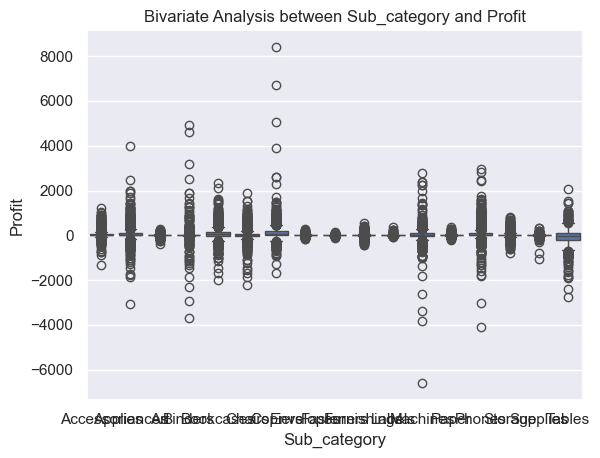

Bivariate Analysis between Sub_category and Quantity


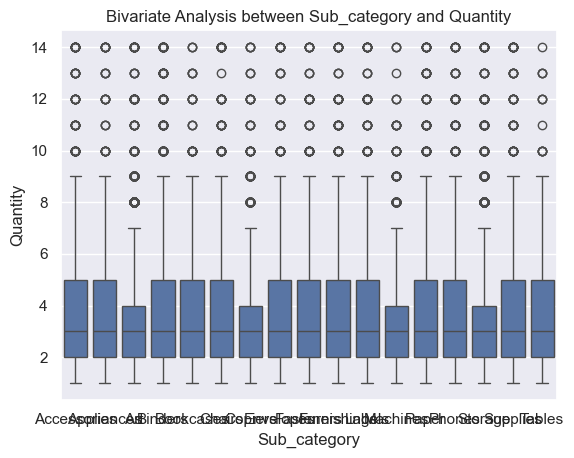

Bivariate Analysis between Sub_category and Sales


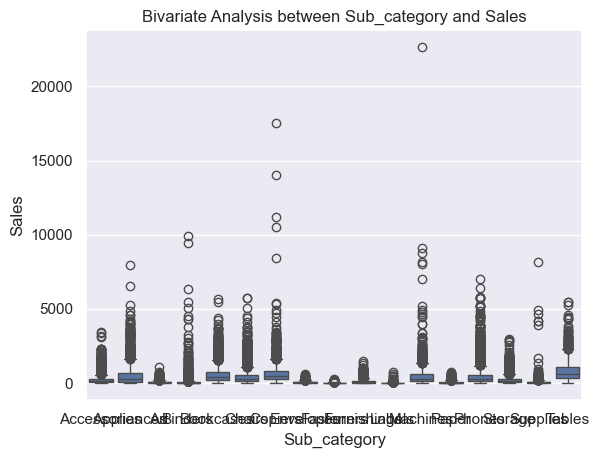

Bivariate Analysis between Sub_category and Shipping_cost


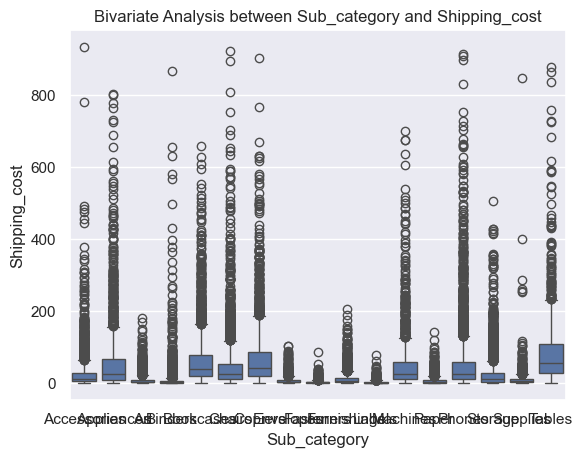

Bivariate Analysis between Sub_category and Year


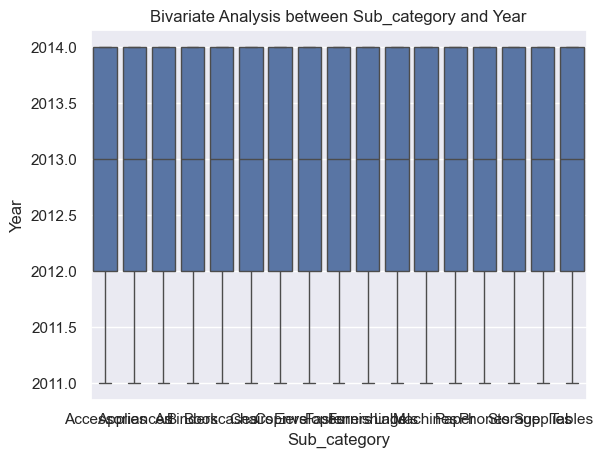

Bivariate Analysis between Sub_category and Weeknum


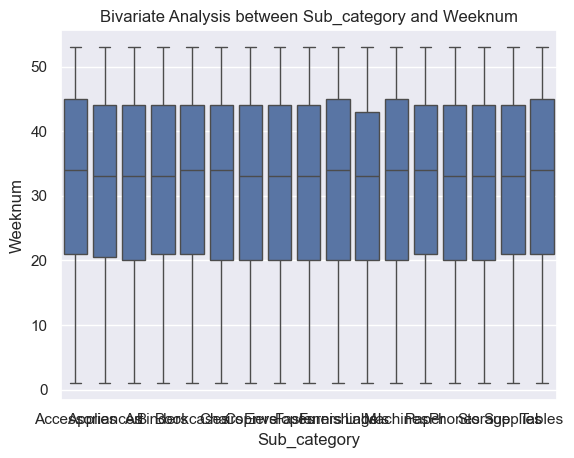

Bivariate Analysis between Market2 and Discount


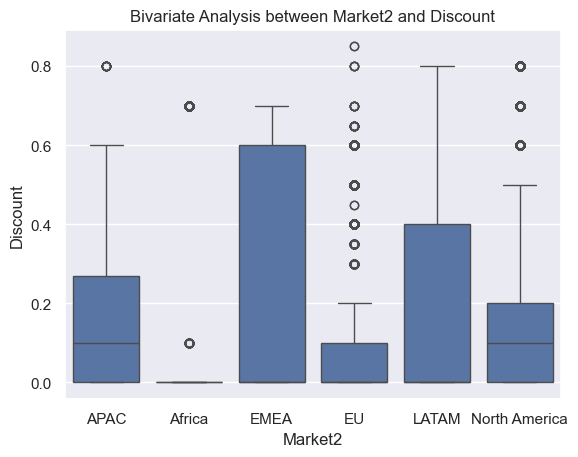

Bivariate Analysis between Market2 and Profit


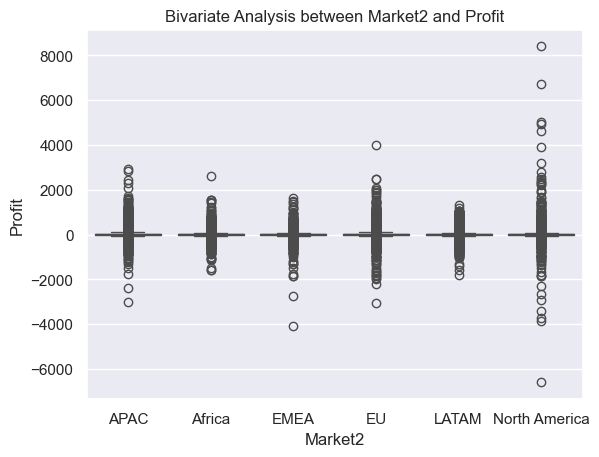

Bivariate Analysis between Market2 and Quantity


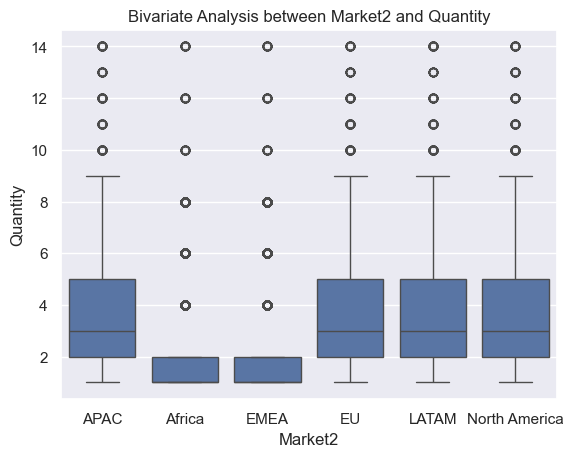

Bivariate Analysis between Market2 and Sales


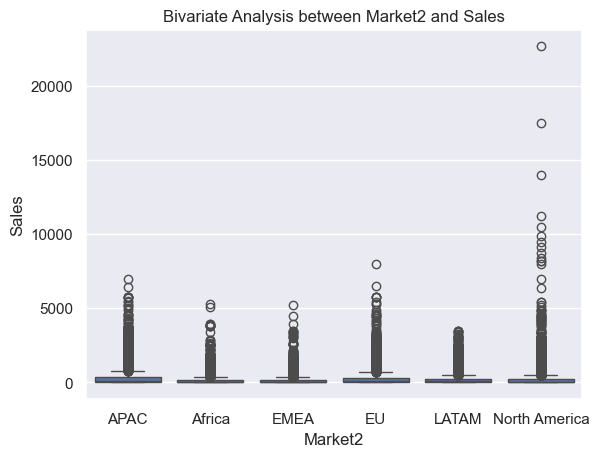

Bivariate Analysis between Market2 and Shipping_cost


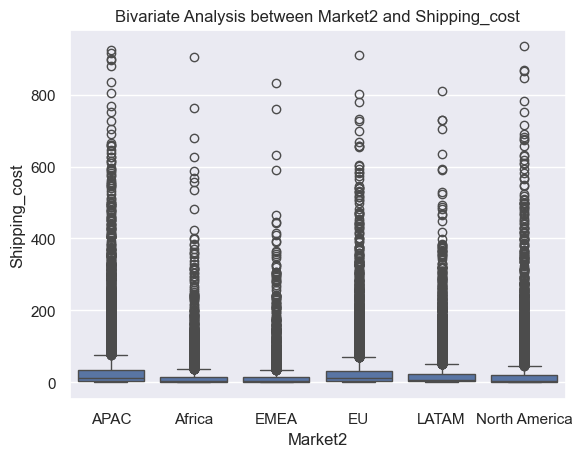

Bivariate Analysis between Market2 and Year


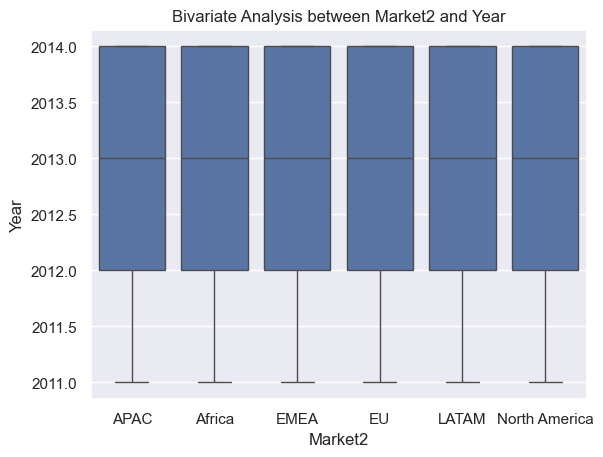

Bivariate Analysis between Market2 and Weeknum


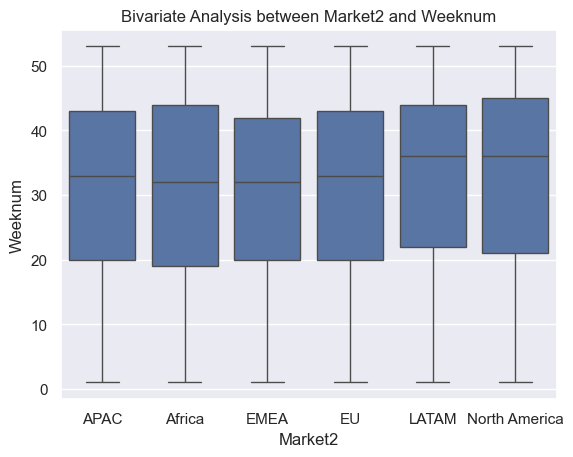

In [175]:
for catf in categorical_features_updated:
    for numf in numerical_features:
        print("="*50)
        print("Bivariate Analysis between {} and {}".format(catf.capitalize(),numf.capitalize()))
        print("="*50)
        plt.figure()
        sns.boxplot(data = data, x = catf, y = numf)
        plt.title("Bivariate Analysis between {} and {}".format(catf.capitalize(),numf.capitalize()))
        plt.xlabel(catf.capitalize())
        plt.ylabel(numf.capitalize())
        plt.show()

<h4>5.a) Profit by Category: Which category has the highest median profit? Which has the lowest? Which category shows the widest spread (largest IQR) in Profit? What does that suggest about profit consistency?</h4>

- The category that has the highest median profit is Technology.
- The category with the lowest is Office Supplies.
- The widest spread also happens to be Technology of around 98.3499 IQR. 
- The profit column in general is plagued with too many outliers. The fact that we have so many negative values suggest that the margins are low because of which any significant discount can cause a huge amount of loss. 

category
Technology         29.940001
Furniture          15.502200
Office Supplies     6.553800
Name: profit, dtype: float32
                  Max_Profit   Min_Profit        IQR
category                                            
Furniture        2316.510010 -2750.280029  81.535001
Office Supplies  4946.370117 -3701.892822  20.130000
Technology       8399.975586 -6599.978027  98.349998


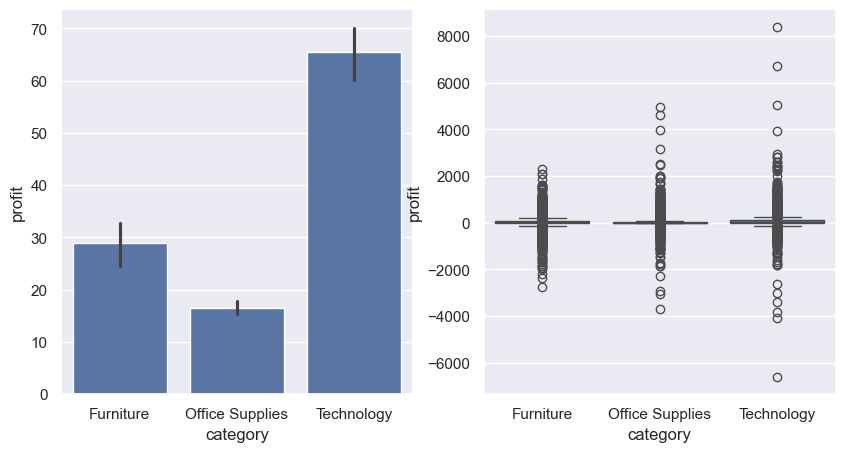

In [130]:
print(data.groupby("category", observed = True)['profit'].median().sort_values(ascending =  False))
def range_func(series):
    return series.max() - series.min()
print(data.groupby("category", observed = True).agg(Max_Profit = ('profit','max'),Min_Profit = ('profit','min'), IQR = ('profit', lambda x: x.quantile(0.75) - x.quantile(0.25))))
fig, ax = plt.subplots(1,2, figsize = (10,5))
sns.barplot(data = data, x = 'category', y = 'profit', ax = ax[0])
sns.boxplot(data = data, x = 'category', y = 'profit', ax = ax[1])
plt.show()

<h4>5.b) Sales by Category: Which category has the highest median sales? Does it also have
the highest median profit?</h4>

- Technology has the highest median sales.
- Yes, it has the highest median profit as well. 

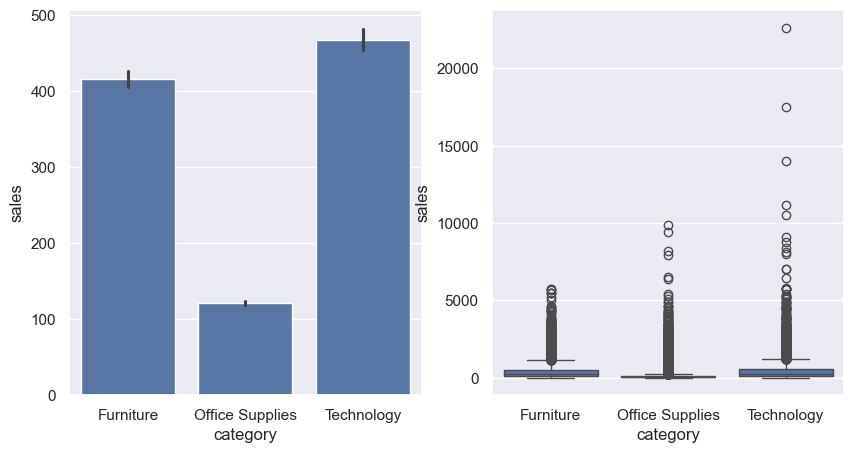

category
Furniture          220.0
Office Supplies     46.0
Technology         260.0
Name: sales, dtype: float64

In [115]:
fig, ax = plt.subplots(1,2, figsize = (10,5))
sns.barplot(data = data, x = 'category', y = 'sales', ax = ax[0])
sns.boxplot(data = data, x = 'category', y = 'sales', ax = ax[1])
plt.show()
data.groupby("category", observed = True)['sales'].median()

<h4>5.c) Profit by Segment: Which segment has the highest median profit? Which segment
has the most negative/low profit outliers?</h4>

- Although all segments are very close to each other in terms of profit, however, the highest median profit happens to be for Home Office.
- Consumers happens to be the segment with most negative/ low profit outliers.

segment
Consumer       9.18000
Corporate      9.31385
Home Office    9.32500
Name: profit, dtype: float32


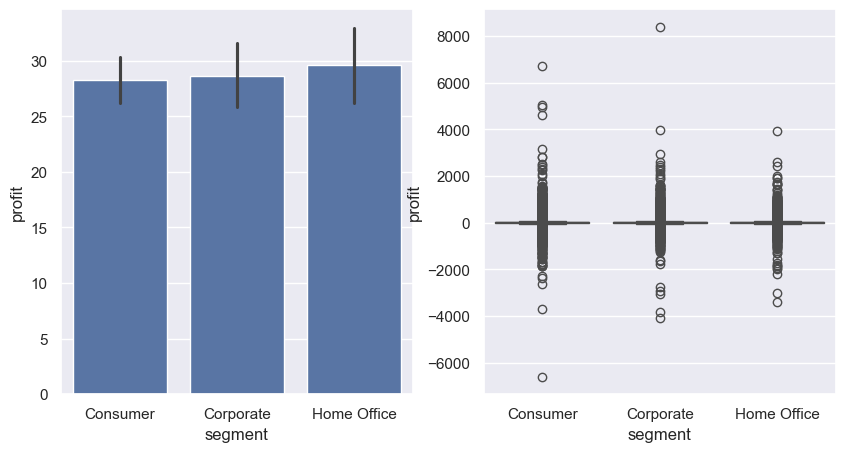

In [132]:
print(data.groupby("segment", observed = True)['profit'].median())
fig, ax = plt.subplots(1,2, figsize = (10,5))
sns.barplot(data = data, x = 'segment', y = 'profit', ax = ax[0])
sns.boxplot(data = data, x = 'segment', y = 'profit', ax = ax[1])
plt.show()

<h4>5.d) Sales by Segment: Which segment has the highest median sales? Is the profit
pattern consistent with sales?</h4>

- The median sales for all three segments is the same, 85.
- The profit pattern is inconsistent with the sales. The median value for sales for all three segments is the same whereas profit outcomes are different. This happens because the spread of profit is very different from sales with respect to the segment. 

segment
Consumer       85.0
Corporate      85.0
Home Office    85.0
Name: sales, dtype: float64


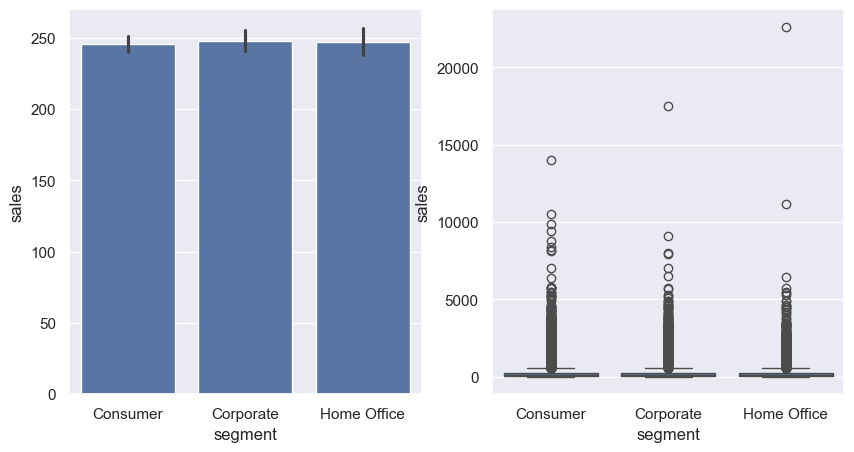

In [133]:
print(data.groupby("segment", observed = True)['sales'].median())
fig, ax = plt.subplots(1,2, figsize = (10,5))
sns.barplot(data = data, x = 'segment', y = 'sales', ax = ax[0])
sns.boxplot(data = data, x = 'segment', y = 'sales', ax = ax[1])
plt.show()

<h3>6. Perform Bivariate Analysis for Market features against Region, Category, and Country</h3>

----------------------------------------------------------------------------------------------------
region  Africa  Canada  Caribbean  Central  Central Asia  EMEA  East  North  \
market                                                                        
APAC         0       0          0        0          2048     0     0      0   
Africa    4587       0          0        0             0     0     0      0   
Canada       0     384          0        0             0     0     0      0   
EMEA         0       0          0        0             0  5029     0      0   
EU           0       0          0     5822             0     0     0   2141   
LATAM        0       0       1690     2972             0     0     0   2644   
US           0       0          0     2323             0     0  2847      0   

region  North Asia  Oceania  South  Southeast Asia  West  
market                                                    
APAC          2338     3487      0            3129     0  
Africa    

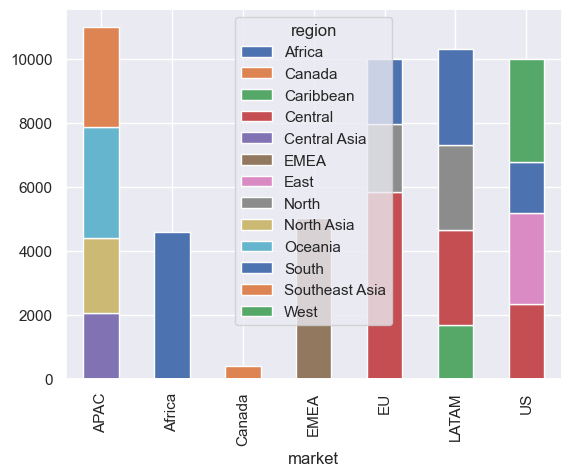

----------------------------------------------------------------------------------------------------
country  Afghanistan  Albania  Algeria  Angola  Argentina  Armenia  Australia  \
market                                                                          
APAC              55        0        0       0          0        0       2837   
Africa             0        0      196     122          0        0          0   
Canada             0        0        0       0          0        0          0   
EMEA               0       16        0       0          0        3          0   
EU                 0        0        0       0          0        0          0   
LATAM              0        0        0       0        390        0          0   
US                 0        0        0       0          0        0          0   

country  Austria  Azerbaijan  Bahrain  ...  United Arab Emirates  \
market                                 ...                         
APAC           0           0     

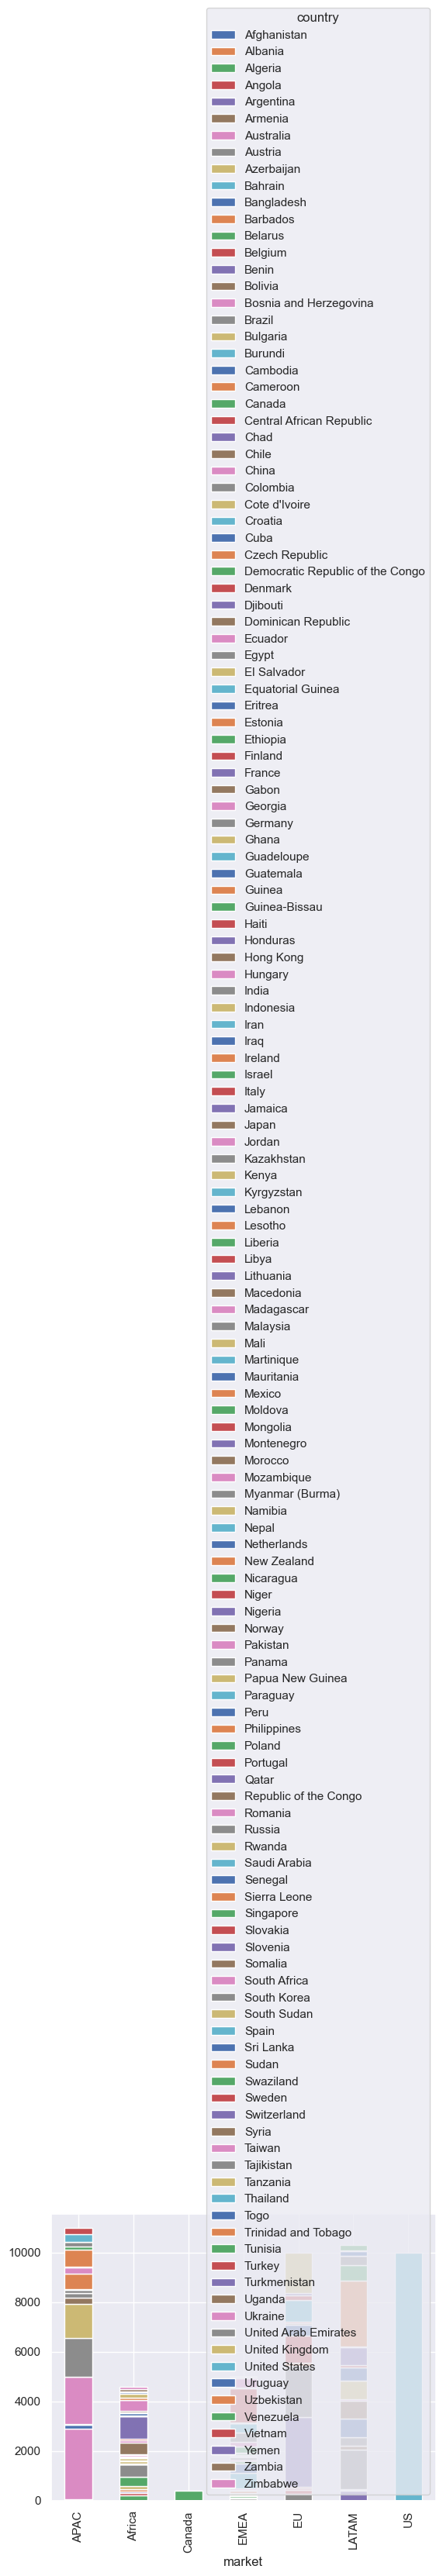

----------------------------------------------------------------------------------------------------
category  Furniture  Office Supplies  Technology
market                                          
APAC           2429             6177        2396
Africa          631             3045         911
Canada           42              277          65
EMEA            770             3297         962
EU             1501             6589        1910
LATAM          2382             5862        2050
US             2121             6018        1847


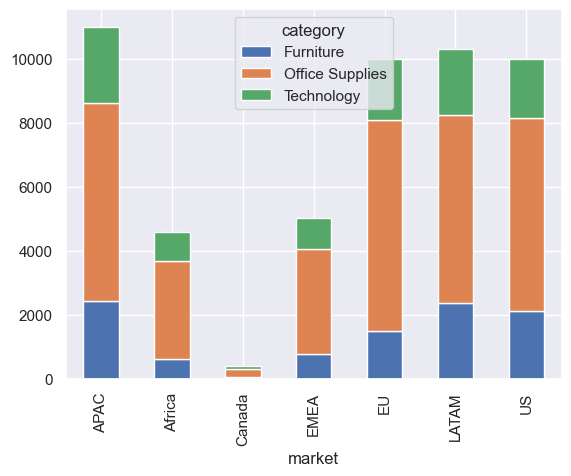

In [149]:
features = {'region','category', 'country'}
for feat in features:
    print('--'*50)
    cont = pd.crosstab(data['market'], data[feat])
    print(cont)
    cont.plot(kind = 'bar', stacked = True)
    plt.show()

<h4>6.a) Is the Market not randomly spread across all Regions?</h4>

No, its not spread across all regions

In [148]:
pd.crosstab(data["market"], data['region'])

region,Africa,Canada,Caribbean,Central,Central Asia,EMEA,East,North,North Asia,Oceania,South,Southeast Asia,West
market,,,,,,,,,,,,,
APAC,0,0,0,0,2048,0,0,0,2338,3487,0,3129,0
Africa,4587,0,0,0,0,0,0,0,0,0,0,0,0
Canada,0,384,0,0,0,0,0,0,0,0,0,0,0
EMEA,0,0,0,0,0,5029,0,0,0,0,0,0,0
EU,0,0,0,5822,0,0,0,2141,0,0,2037,0,0
LATAM,0,0,1690,2972,0,0,0,2644,0,0,2988,0,0
US,0,0,0,2323,0,0,2847,0,0,0,1620,0,3196


<Axes: xlabel='market'>

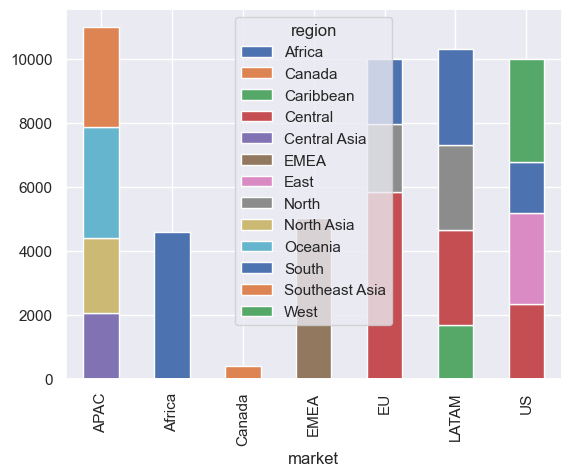

In [150]:
pd.crosstab(data["market"], data['region']).plot(kind = 'bar', stacked = 'True')

<h4>6.b) Which country has negligible office supply orders?</h4>

South Sudan and Burundi have negligible office supplies orders

In [146]:
pd.crosstab(data['country'],data['category'])['Office Supplies'].sort_values(ascending = False)

country
United States    6018
France           1854
Australia        1608
Mexico           1492
Germany          1348
                 ... 
Eritrea             1
Bahrain             1
Armenia             1
Burundi             0
South Sudan         0
Name: Office Supplies, Length: 147, dtype: int64

<h4>6.c) What are the most useful insights?</h4>

- The most important insight is that the market is same as the region in most cases which means that approximatley all the orders are placed locally.
- Orders are placed for all product categories in all the regions which mean all the superstores need to contain all product categories to operate well. 